<a href="https://colab.research.google.com/github/paulopontes01/ML1/blob/main/analise_imoveis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Preditiva do Mercado Imobiliário em Sorocaba
## Previsão da Probabilidade de Comercialização de Imóveis da Lima Imobiliária

### Contexto de Negócio
A LIMA IMÓVEIS iniciou suas atividades em 1973 visando construir a sua história no mercado imobiliário de Sorocaba, de forma sólida, confiável e duradoura.Tem sede própria, com amplo estacionamento no Jardim Paulistano. Trata-se de imobiliária atuante no mercado, com um histórico íntegro e de ótimas negociações. Ética profissional e transparência são imprescindíveis no mercado imobiliário.
A imobiliária recebe diariamente leads (contatos) por meio de portais como OLX e ImobiBrasil. O time comercial enfrenta dois desafios práticos:

1. **Priorização:** com dezenas de imóveis no portfólio, para quais vale dedicar mais esforço?
2. **Diagnóstico:** por que alguns imóveis acumulam muitos contatos mas nunca fecham negócio?

Este projeto usa **Machine Learning** para responder essas perguntas —
atribuindo a cada imóvel disponível uma **probabilidade de ser comercializado**,
e identificando quais características mais influenciam esse desfecho.

---

### Perguntas que este projeto responde

| # | Pergunta | Técnica |
|---|---|---|
| 1 | Quais imóveis e bairros têm maior demanda? | EDA + Visualização |
| 2 | Quando os clientes mais procuram atendimento? | Análise temporal |
| 3 | Existem perfis distintos de imóveis no portfólio? | Clusterização K-Means |
| 4 | Qual a probabilidade de cada imóvel ser comercializado? | Regressão Logística |
| 5 | Quais características mais influenciam a comercialização? | Feature Importance + Odds Ratio |

---

### Bases de Dados

| Arquivo | Registros | Descrição |
|---|---|---|
| `arquivo_*.xls` | ~4.500 | Contatos/leads recebidos via portal |
| `Imoveis.csv` | ~467 | Catálogo com características, valores e localização |
| `cadastros_*.xls` | ~634 | Perfis de clientes e proprietários |

**Chave de junção:** código do imóvel — presente como `Referência` em Imóveis
e embutido no texto da coluna `Imóvel` nos Contatos (ex: `"Cód. - 789 Casa para Locação"`).

---

### Limitações Conhecidas dos Dados

- **Ausência de data de fechamento:** não sabemos *quando* o imóvel foi comercializado,
  apenas *se* foi — o que impede análise de tempo até fechamento.
- **Viés de exposição:** imóveis mais antigos acumularam mais contatos naturalmente,
  independente da qualidade do imóvel.
- **Dados faltantes:** valores "Consultar Valor" e características não preenchidas
  são imputados pela mediana dentro do Pipeline.
- **Granularidade geográfica:** usamos bairro como proxy de localização;
  imóveis no mesmo bairro podem ter acessibilidades muito distintas.

---

### Roteiro do Projeto *(alinhado à Aula 06 — Projeto de Ponta a Ponta)*

1. Instalação e importação das bibliotecas
2. Carregamento e limpeza dos dados (whitelist de colunas)
3. ETL — criação da tabela unificada (`df_master`)
4. **Análise Exploratória:** histogramas, correlações, scatter matrix, padrões temporais
5. **Mapa geográfico** de demanda por bairro
6. **Clusterização K-Means** — Cotovelo + Silhouette Score + impacto no modelo
7. **Pipeline** de pré-processamento (`ColumnTransformer`)
8. **Regressão Logística** — modelo principal + validação cruzada
9. Comparativo de modelos + `RandomizedSearchCV`
10. Avaliação final + **Odds Ratio** (interpretação em linguagem de negócio)
11. Scoring de imóveis ativos + `joblib`
12. Conclusão quantitativa com Gain Chart e exportação

---
## 1. Instalação das Bibliotecas

In [2]:
# Instalação das bibliotecas que podem não estar disponíveis por padrão no Colab.
!pip install folium requests openpyxl -q

---
## 2. Importação das Bibliotecas

In [3]:
# ── Manipulação de dados
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
from pandas.plotting import scatter_matrix   # igual à Aula 06

# ── Pré-processamento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Avaliação
from sklearn.model_selection import (
    train_test_split, StratifiedShuffleSplit,
    cross_val_score, cross_val_predict,
    RandomizedSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)

# ── Clusterização e redução de dimensionalidade
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score   # Aula 11

# ── Persistência do modelo (Aula 06 — seção joblib)
import joblib

# ── Geolocalização
import requests, time
from urllib.parse import quote

# ── Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
## 3. Carregamento e Limpeza dos Dados

In [4]:
# ── Upload dos arquivos no Google Colab

from google.colab import files
print('Selecione os arquivos: Contatos (xls/csv), Imoveis (xls/csv), Cadastros (xls/csv)')
uploaded = files.upload()
print('\nArquivos recebidos:', list(uploaded.keys()))

Selecione os arquivos: Contatos (xls/csv), Imoveis (xls/csv), Cadastros (xls/csv)


Saving contatos.xls to contatos.xls
Saving cadastros.xls to cadastros.xls
Saving imoveis.xls to imoveis.xls

Arquivos recebidos: ['contatos.xls', 'cadastros.xls', 'imoveis.xls']


In [5]:
# O cliente exporta em .xls mas também tem csv
def ler_arquivo(nome_arquivo):
    ext = os.path.splitext(nome_arquivo)[1].lower()
    if ext == '.xls':
        return pd.read_html(nome_arquivo)[0]
    elif ext in ('.csv', '.txt'):
        # Encoding latin-1 para suportar acentuação brasileira
        return pd.read_csv(nome_arquivo, encoding='latin-1', sep=None, engine='python')
    else:
        return pd.read_excel(nome_arquivo)

def encontrar_arquivo(palavras_chave, arquivos):
    """Retorna o primeiro arquivo cujo nome contenha alguma das palavras-chave.
    Isso garante compatibilidade com qualquer nome de export do sistema."""
    for kw in palavras_chave:
        for a in arquivos:
            if kw.lower() in a.lower():
                return a
    return None

# ── Identificar e carregar cada base
arquivos = list(uploaded.keys())

arq_contatos  = encontrar_arquivo(['arquivo', 'contato', 'Contatos'], arquivos)
arq_imoveis   = encontrar_arquivo(['imoveis', 'imóveis', 'Imoveis'],  arquivos)
arq_cadastros = encontrar_arquivo(['cadastro', 'Cadastros'],           arquivos)

print(f'Contatos  → {arq_contatos}')
print(f'Imóveis   → {arq_imoveis}')
print(f'Cadastros → {arq_cadastros}')

df_contatos_raw  = ler_arquivo(arq_contatos)
df_imoveis_raw   = ler_arquivo(arq_imoveis)
df_cadastros_raw = ler_arquivo(arq_cadastros)

print(f'\nLidos — Contatos: {df_contatos_raw.shape} | Imóveis: {df_imoveis_raw.shape} | Cadastros: {df_cadastros_raw.shape}')

Contatos  → contatos.xls
Imóveis   → imoveis.xls
Cadastros → cadastros.xls

Lidos — Contatos: (4577, 14) | Imóveis: (467, 32) | Cadastros: (662, 19)


In [6]:
# Estratégia: whitelist — definimos exatamente o que queremos manter.
# Tudo que não estiver na lista é descartado automaticamente.
# Critérios de exclusão:
#   • >80% de valores nulos (ex: Telefone 3, Telefone Internacional)
#   • Dados sensíveis sem valor analítico (CPF, RG, CNPJ)
#   • Colunas duplicadas ou redundantes (Nome Fantasia, Razão Social)
#   • Metadados do sistema que não agregam ao modelo (Tipo, Importante, Remetente)

COLUNAS_CONTATOS = [
    'Data',
    'Nome Contato',
    'Telefone',
    'Cidade',
    'Mensagem',
    'Imóvel',
]

COLUNAS_IMOVEIS = [
    'Referência',       # chave primária
    'Disponibilidade',  # (Alugado / Vendido / etc.)
    'Finalidade',       # Venda / Locação
    'Tipo',             # Casa, Apartamento, etc.
    'Cidade',
    'Bairro',
    'CEP',
    'Características',  # → dormitórios, banheiros, garagens (extração via regex)
    'Valor',
    'Valor IPTU',
    'Valor Condomínio',
    'Valor m²',
    'Corretor Nome',    # análise de performance
    'Atualizado em',
]

COLUNAS_CADASTROS = [
    'Perfil',        # Proprietário / Cliente
    'Pessoa',        # Física / Jurídica
    'Nome',
    'Telefone 1',
    'Telefone 2',
    'E-mail',
    'Status',        # Ativo / Inativo
    'Cliente Desde', # tempo de relacionamento com a imobiliária
    'Captação',      # canal de origem do cadastro
]

# Filtrar apenas as colunas que existem no arquivo
df_contatos  = df_contatos_raw[ [c for c in COLUNAS_CONTATOS  if c in df_contatos_raw.columns]].copy()
df_imoveis   = df_imoveis_raw[  [c for c in COLUNAS_IMOVEIS   if c in df_imoveis_raw.columns]].copy()
df_cadastros = df_cadastros_raw[[c for c in COLUNAS_CADASTROS  if c in df_cadastros_raw.columns]].copy()

# Relatório de limpeza
print('Resultado da limpeza de colunas:')
for nome, raw, limpo in [('Contatos',  df_contatos_raw,  df_contatos),
                          ('Imóveis',   df_imoveis_raw,   df_imoveis),
                          ('Cadastros', df_cadastros_raw, df_cadastros)]:
    removidas = raw.shape[1] - limpo.shape[1]
    print(f'   {nome:10s}: {raw.shape[1]:2d} → {limpo.shape[1]:2d} colunas  (removidas: {removidas})')

Resultado da limpeza de colunas:
   Contatos  : 14 →  6 colunas  (removidas: 8)
   Imóveis   : 32 → 14 colunas  (removidas: 18)
   Cadastros : 19 →  9 colunas  (removidas: 10)


In [7]:
# Equivalente ao housing.head() / housing.info() da Aula 06

print('=== CONTATOS ===')
display(df_contatos.head(3))

print(f'\nShape: {df_contatos.shape[0]:,} linhas × {df_contatos.shape[1]} colunas')

print('\nTipos de dados:')
display(df_contatos.dtypes)

print('\nNulos por coluna (% do total):')
nulos = (df_contatos.isnull().sum() / len(df_contatos) * 100).round(1)
display(nulos[nulos > 0].sort_values(ascending=False))

=== CONTATOS ===


,Data,Nome Contato,Telefone,Cidade,Mensagem,Imóvel
0,30/05/2026 às 20:38:04,LeehProenca,(15) 99103-7588,NaN,"Você recebeu esta mensagem através do portal Grupo OLX, ...","Cód. - 789 Casa para Locação R$ 990,00"
1,30/05/2026 às 19:08:04,Kellen,(15) 99718-0927,NaN,"Você recebeu esta mensagem através do portal Grupo OLX, ...","Cód. - 785 Apartamento para Locação R$ 1.200,00"
2,30/05/2026 às 15:00:23,Jade Almeida,(15) 98135-9459,NaN,"Você recebeu esta mensagem através do portal Grupo OLX, ...","Cód. - 789 Casa para Locação R$ 990,00"



Shape: 4,577 linhas × 6 colunas

Tipos de dados:


,0
Data,object
Nome Contato,object
Telefone,object
Cidade,float64
Mensagem,object
Imóvel,object



Nulos por coluna (% do total):


,0
Cidade,100.0
Imóvel,16.4
Telefone,0.9


In [8]:
print('=== IMÓVEIS ===')
display(df_imoveis.head(3))

# describe() — resumo estatístico de atributos numéricos (igual à Aula 06)
print('\nEstatísticas descritivas:')
display(df_imoveis.describe())

print('\nDisponibilidade (variável-alvo):')
display(df_imoveis['Disponibilidade'].value_counts(dropna=False))

print('\nFinalidade:')
display(df_imoveis['Finalidade'].value_counts())

print('\nTipo de imóvel:')
display(df_imoveis['Tipo'].value_counts())

=== IMÓVEIS ===


,Referência,Disponibilidade,Finalidade,Tipo,Cidade,Bairro,CEP,Características,Valor,Valor IPTU,Valor Condomínio,Valor m²,Corretor Nome,Atualizado em
0,113,NaN,Venda,Casa,Sorocaba / SP,Jardim Pagliato,18046-152,3 dormitórios | 3 suítes | 4 banheiros | 4 garagens |,Consultar Valor,NaN,NaN,NaN,Sebastião A. de Lima,24/09/2024 12:18:03
1,594,Alugado,Locação,Casa,Sorocaba / SP,Jardim Maria do Carmo,18081-110,1 dormitório | 1 banheiro |,"R$ 600,00","R$ 25,00",NaN,NaN,Sebastião A. de Lima,28/11/2024 17:50:35
2,107,Vendido,Locação,Apartamento,Sorocaba / SP,Jardim Guadalajara,18045-530,2 dormitórios | 1 banheiro | 1 garagem |,"R$ 750,00","R$ 50,00","R$ 220,00",NaN,Sebastião A. de Lima,05/07/2024 12:20:30



Estatísticas descritivas:


,Referência,Disponibilidade,Finalidade,Tipo,Cidade,Bairro,CEP,Características,Valor,Valor IPTU,Valor Condomínio,Valor m²,Corretor Nome,Atualizado em
count,465,237,467,467,467,467,467,417,467,379,262,188,464,467
unique,442,5,2,28,12,165,289,133,248,224,159,179,9,467
top,J792,Alugado,Venda,Apartamento,Sorocaba / SP,Parque Campolim,18048-115,2 dormitórios | 1 banheiro | 1 garagem |,"R$ 1.200,00","R$ 50,00","R$ 300,00","R$ 5.263,00",Lima Imóveis,20/03/2026 11:45:30
freq,2,87,251,148,386,54,29,61,11,13,10,3,174,1



Disponibilidade (variável-alvo):


,count
Disponibilidade,
NaN,230
Alugado,87
Desistência,73
Outros,31
Disponível,24
Vendido,22



Finalidade:


,count
Finalidade,
Venda,251
Locação,216



Tipo de imóvel:


,count
Tipo,
Apartamento,148
Casa em Condomínio,118
Casa,104
Terreno,12
Lote em Condomínio Fechado,11
Comercial,9
Sala Comercial,8
Lote,8
Chácara,7


In [9]:
print('=== CADASTROS ===')
display(df_cadastros.head(3))

print('\nPerfis:')
display(df_cadastros['Perfil'].value_counts(dropna=False))

print('\nStatus:')
display(df_cadastros['Status'].value_counts(dropna=False))

=== CADASTROS ===


,Perfil,Pessoa,Nome,Telefone 1,Telefone 2,E-mail,Status,Cliente Desde,Captação
0,Proprietário,Física,Abdala Mostafa Neto,NaN,(15) 99756-3266,NaN,Ativo,06/06/2024,NaN
1,Proprietário,Física,Adalberto G. Gimenes,NaN,(15) 99617-1205,AdalbertoGimenes@yahoo.com,Ativo,31/05/2024,NaN
2,Proprietário,Física,Adalberto G. Gimenes,NaN,(19) 7831-464,NaN,Ativo,07/04/2026,NaN



Perfis:


,count
Perfil,
Proprietário,538
Cliente,90
Corretor,28
"Cliente, quer casa em condominio, data 01/12/2024",1
"Cliente, Proprietário, Atendiddo por Narlon, lead veio pela placa na rua, cod 585 tambem é proprietário de um imóvel",1
"Cliente, Lead enviado para a alessandra. Esta com dinheiro.",1
"Cliente, (o que o corretor quiser colocar)",1
"Cliente, esse e bom, financiamneto aprovado - anglica pre....",1
"Cliente, Contato feito na sexta dia 5 de julho - teste",1



Status:


,count
Status,
Ativo,662


---
## 4. Tratamento dos Dados e Criação da Tabela Unificada (ETL)

Nesta etapa transformamos os dados brutos em um único DataFrame analítico (`df_master`),
pronto para a modelagem. As principais operações são:
- Parsing de datas e extração de features temporais
- Extração do código do imóvel a partir de texto livre
- Conversão de valores monetários (`R$ 1.200,00` → `float`)
- Extração de características (dormitórios, banheiros, garagens) via expressão regular
- Criação da **variável-alvo** `comercializado`
- Merge das três tabelas

In [10]:
# Formato original: "30/05/2026 às 19:08:04" para datetime do pandas.

df_contatos['Data'] = (
    df_contatos['Data']
    .str.replace(' às ', ' ', regex=False)
    .pipe(pd.to_datetime, format='%d/%m/%Y %H:%M:%S', errors='coerce')
)

# Extração de features temporais — cada uma vira uma coluna usável no modelo
df_contatos['hora']       = df_contatos['Data'].dt.hour
df_contatos['dia_semana'] = df_contatos['Data'].dt.dayofweek  # 0=Segunda, 6=Domingo
df_contatos['mes']        = df_contatos['Data'].dt.month

# Turno — agrupa as horas em períodos do dia para facilitar a análise
df_contatos['turno'] = pd.cut(
    df_contatos['hora'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Madrugada', 'Manhã', 'Tarde', 'Noite']
)

# Mapeamento dos números de dia para nomes (usado nos gráficos)
dias_map = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sáb', 6: 'Dom'}

print('Datas tratadas. Amostra:')
display(df_contatos[['Data', 'hora', 'dia_semana', 'turno']].head())

Datas tratadas. Amostra:


,Data,hora,dia_semana,turno
0,2026-05-30 20:38:04,20,5,Noite
1,2026-05-30 19:08:04,19,5,Noite
2,2026-05-30 15:00:23,15,5,Tarde
3,2026-05-30 09:50:14,9,5,Manhã
4,2026-05-29 22:26:15,22,4,Noite


In [11]:
# A coluna "Imóvel" contém texto livre no formato:
# "Cód. - 789 Casa para Locação R$ 990,00"
# Precisamos isolar apenas o número (789) para fazer o JOIN com df_imoveis.

def extrair_codigo(texto):
    """Extrai o número após 'Cód. -' usando expressão regular."""
    if pd.isna(texto):
        return np.nan
    match = re.search(r'Cód\.\s*-\s*(\d+)', str(texto))
    return int(match.group(1)) if match else np.nan

df_contatos['cod_imovel'] = df_contatos['Imóvel'].apply(extrair_codigo)

print(f'Contatos com código extraído: {df_contatos["cod_imovel"].notna().sum():,} '
      f'({df_contatos["cod_imovel"].notna().mean():.1%})')
display(df_contatos[['Imóvel', 'cod_imovel']].dropna().head(5))

Contatos com código extraído: 3,629 (79.3%)


,Imóvel,cod_imovel
0,"Cód. - 789 Casa para Locação R$ 990,00",789.0
1,"Cód. - 785 Apartamento para Locação R$ 1.200,00",785.0
2,"Cód. - 789 Casa para Locação R$ 990,00",789.0
3,"Cód. - 802 Apartamento para Locação R$ 1.400,00",802.0
4,"Cód. - 758 Casa para Venda R$ 210.000,00",758.0


In [12]:
# Cada linha em df_contatos representa uma pessoa interessada num imóvel.
# O total de contatos por imóvel é o nosso indicador de demanda.

demanda = (
    df_contatos
    .dropna(subset=['cod_imovel'])
    .groupby('cod_imovel')
    .size()
    .reset_index(name='total_contatos')
)

print(f'Imóveis com pelo menos 1 contato: {len(demanda)}')
print('\nTop 10 mais procurados:')
display(demanda.sort_values('total_contatos', ascending=False).head(10))

Imóveis com pelo menos 1 contato: 224

Top 10 mais procurados:


,cod_imovel,total_contatos
87,584.0,259
89,594.0,220
125,647.0,205
47,481.0,149
137,668.0,134
217,789.0,130
123,644.0,100
191,749.0,96
220,795.0,83
116,634.0,73


In [13]:
# Valores chegam como string: "R$ 1.200,00"
# Precisamos converter para float: 1200.0

def limpar_valor(v):
    """Converte string de valor monetário brasileiro para float."""
    if pd.isna(v) or str(v).strip() in ['', 'Consultar Valor']:
        return np.nan
    v = re.sub(r'[R$\s]', '', str(v))        # remove "R$" e espaços
    v = v.replace('.', '').replace(',', '.')   # 1.200,00 → 1200.00
    try:
        return float(v)
    except ValueError:
        return np.nan

for col in ['Valor', 'Valor IPTU', 'Valor Condomínio', 'Valor m²']:
    df_imoveis[col + '_num'] = df_imoveis[col].apply(limpar_valor)

print('Valores convertidos para numérico:')
display(df_imoveis[['Referência', 'Valor', 'Valor_num']].head(6))

Valores convertidos para numérico:


,Referência,Valor,Valor_num
0,113,Consultar Valor,NaN
1,594,"R$ 600,00",600.0
2,107,"R$ 750,00",750.0
3,601,"R$ 900,00",900.0
4,789,"R$ 990,00",990.0
5,108,"R$ 1.000,00",1000.0


In [14]:
# A coluna "Características" contém texto no formato:
# "3 dormitórios | 2 suítes | 4 banheiros | 4 garagens |"
# Usamos regex para extrair cada número como uma coluna numérica separada.

def extrair_caracteristica(texto, padrao):
    """Extrai a quantidade de um atributo específico do texto de características.
    Ex: extrair_caracteristica('2 dormitórios | 1 banheiro |', 'dormitório') → 2
    """
    if pd.isna(texto):
        return 0
    match = re.search(r'(\d+)\s+' + padrao, str(texto), re.IGNORECASE)
    return int(match.group(1)) if match else 0

df_imoveis['dormitorios'] = df_imoveis['Características'].apply(
    lambda x: extrair_caracteristica(x, 'dormitório'))
df_imoveis['suites']      = df_imoveis['Características'].apply(
    lambda x: extrair_caracteristica(x, 'suíte'))
df_imoveis['banheiros']   = df_imoveis['Características'].apply(
    lambda x: extrair_caracteristica(x, 'banheiro'))
df_imoveis['garagens']    = df_imoveis['Características'].apply(
    lambda x: extrair_caracteristica(x, 'garagem'))

print('Características extraídas:')
display(df_imoveis[['Referência', 'dormitorios', 'suites', 'banheiros', 'garagens']].head(8))

Características extraídas:


,Referência,dormitorios,suites,banheiros,garagens
0,113,3,3,4,0
1,594,1,0,1,0
2,107,2,0,1,1
3,601,2,0,1,1
4,789,1,1,1,0
5,108,0,0,1,1
6,581/L,2,0,0,1
7,727,2,0,1,1


In [15]:
# ──────────────────────────────────────────────
# 4.6 Criar variável-alvo: imóvel foi comercializado?
# ──────────────────────────────────────────────
# Esta é a variável que o modelo vai tentar prever (y).
# Regra de negócio:
#   Disponibilidade == "Alugado" ou "Vendido"  →  1 (comercializado com sucesso)
#   Demais valores (Desistência, Outros, NaN)  →  0 (não comercializado)

df_imoveis['comercializado'] = (
    df_imoveis['Disponibilidade']
    .isin(['Alugado', 'Vendido'])
    .astype(int)
)

print('Distribuição da variável-alvo:')
print(df_imoveis['comercializado'].value_counts())
print()
# Distribuição detalhada para entender o que compõe cada classe
print('Detalhe por status de disponibilidade:')
display(df_imoveis['Disponibilidade'].value_counts(dropna=False))

Distribuição da variável-alvo:
comercializado
0    358
1    109
Name: count, dtype: int64

Detalhe por status de disponibilidade:


,count
Disponibilidade,
NaN,230
Alugado,87
Desistência,73
Outros,31
Disponível,24
Vendido,22


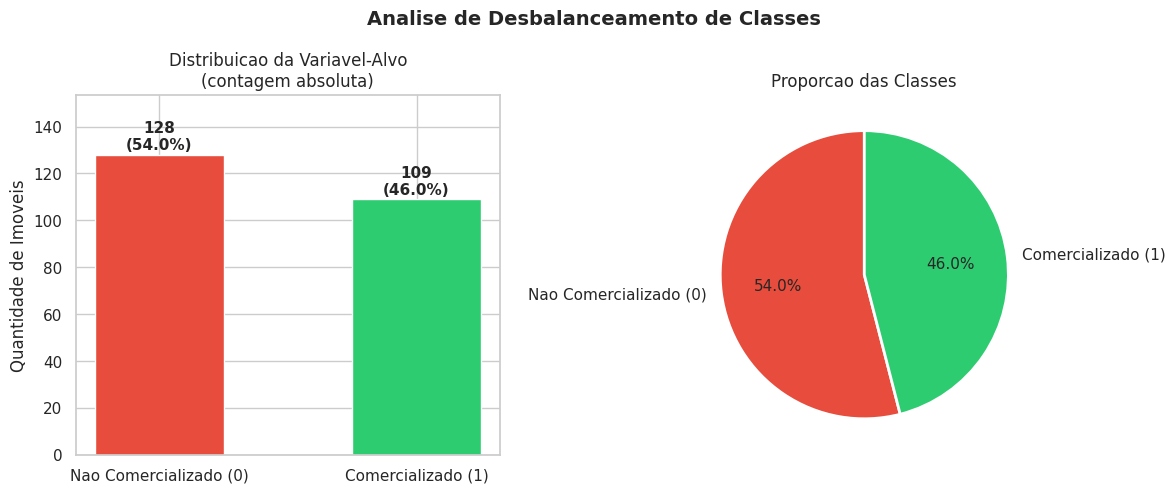


Resumo do desbalanceamento:
   Nao Comercializados : 128 imoveis (54.0%)
   Comercializados     : 109 imoveis (46.0%)
   Razao entre classes : 1.2:1

Classes razoavelmente balanceadas (razao <= 3:1)


In [57]:
# ──────────────────────────────────────────────
# 4.6b Análise do desbalanceamento de classes
# ──────────────────────────────────────────────
# Antes de modelar, é essencial verificar se as classes são balanceadas.
# Em problemas reais é comum ter muito mais exemplos de uma classe do que de outra.
#
# Exemplo do problema: se 80% dos imóveis NAO foram comercializados,
# um modelo que sempre prevê 'nao comercializado' teria 80% de acurácia
# sem aprender absolutamente nada útil.
#
# Por isso usaremos AUC-ROC e F1-Score como métricas principais,
# e class_weight='balanced' no modelo para compensar o desbalanceamento.

df_modelo_temp = df_imoveis[df_imoveis['Disponibilidade'].notna()]
contagem  = df_modelo_temp['comercializado'].value_counts()
proporcao = df_modelo_temp['comercializado'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels    = ['Nao Comercializado (0)', 'Comercializado (1)']
cores_cls = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, contagem.values, color=cores_cls, edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(contagem.values, proporcao.values)):
    axes[0].text(i, v + 2, f'{v}\n({p:.1%})', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribuicao da Variavel-Alvo\n(contagem absoluta)', fontsize=12)
axes[0].set_ylabel('Quantidade de Imoveis')
axes[0].set_ylim(0, max(contagem.values) * 1.2)

axes[1].pie(contagem.values, labels=labels, colors=cores_cls,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporcao das Classes', fontsize=12)

plt.suptitle('Analise de Desbalanceamento de Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

razao = contagem.max() / contagem.min()
print(f'\nResumo do desbalanceamento:')
print(f'   Nao Comercializados : {contagem[0]:3d} imoveis ({proporcao[0]:.1%})')
print(f'   Comercializados     : {contagem[1]:3d} imoveis ({proporcao[1]:.1%})')
print(f'   Razao entre classes : {razao:.1f}:1')
print()
if razao > 3:
    print('CLASSES DESBALANCEADAS (razao > 3:1)')
    print('   Impacto : acuracia simples seria enganosa como metrica principal.')
    print('   Solucao : class_weight=balanced na Regressao Logistica.')
    print('   Metricas corretas: AUC-ROC, F1-Score, Precision, Recall.')
else:
    print('Classes razoavelmente balanceadas (razao <= 3:1)')

In [16]:
# ──────────────────────────────────────────────
# 4.7 Simplificar tipos de imóvel
# ──────────────────────────────────────────────
# O campo "Tipo" tem 28 categorias distintas, muitas com apenas 1 ou 2 registros.
# Agrupamos em 5 categorias maiores para evitar que categorias raras prejudiquem o modelo (problema de alta cardinalidade).

def simplificar_tipo(t):
    """Agrupa os 28 tipos de imóvel em 5 categorias representativas."""
    t = str(t)
    if 'Apartamento' in t or 'Flat' in t or 'Studio' in t:
        return 'Apartamento'
    elif 'Casa' in t or 'Sobrado' in t:
        return 'Casa'
    elif 'Terreno' in t or 'Lote' in t or 'Área' in t:
        return 'Terreno/Lote'
    elif any(p in t for p in ['Comercial', 'Salão', 'Barracão', 'Galpão', 'Loja', 'Sala']):
        return 'Comercial'
    else:
        return 'Outro'

df_imoveis['tipo_simples'] = df_imoveis['Tipo'].apply(simplificar_tipo)

print('Distribuição do tipo simplificado:')
display(df_imoveis['tipo_simples'].value_counts())

Distribuição do tipo simplificado:


,count
tipo_simples,
Casa,234
Apartamento,158
Terreno/Lote,34
Comercial,32
Outro,9


In [19]:
# ──────────────────────────────────────────────
# 4.8 Merge — criar a TABELONA (df_master)
# ──────────────────────────────────────────────
# Unimos df_imoveis com a contagem de demanda.
# Usamos left join para manter todos os imóveis,
# mesmo os que não receberam nenhum contato (total_contatos = 0).

# Converter a coluna 'Referência' em df_imoveis para o tipo numérico (int) para compatibilidade com 'cod_imovel'
df_imoveis['Referência'] = pd.to_numeric(df_imoveis['Referência'], errors='coerce').astype('Int64')
demanda['cod_imovel'] = demanda['cod_imovel'].astype('Int64')

df_master = df_imoveis.merge(
    demanda,
    left_on='Referência',
    right_on='cod_imovel',
    how='left'
)
df_master['total_contatos'] = df_master['total_contatos'].fillna(0).astype(int)

print(f'Tabela criada: {df_master.shape[0]} imóveis × {df_master.shape[1]} colunas')
print(f'   Imóveis com ao menos 1 contato: {(df_master["total_contatos"] > 0).sum()}')
print(f'   Imóveis sem nenhum contato    : {(df_master["total_contatos"] == 0).sum()}')

display(df_master[['Referência', 'tipo_simples', 'Bairro', 'Finalidade',
                   'Valor_num', 'dormitorios', 'garagens',
                   'total_contatos', 'comercializado']].head(8))

Tabela criada: 467 imóveis × 26 colunas
   Imóveis com ao menos 1 contato: 214
   Imóveis sem nenhum contato    : 253


,Referência,tipo_simples,Bairro,Finalidade,Valor_num,dormitorios,garagens,total_contatos,comercializado
0,113,Casa,Jardim Pagliato,Venda,NaN,3,0,0,0
1,594,Casa,Jardim Maria do Carmo,Locação,600.0,1,0,220,1
2,107,Apartamento,Jardim Guadalajara,Locação,750.0,2,1,0,1
3,601,Apartamento,Aparecidinha,Locação,900.0,2,1,27,1
4,789,Casa,Vila Jardini,Locação,990.0,1,0,130,0
5,108,Comercial,Vila Santana,Locação,1000.0,0,1,4,0
6,<NA>,Casa,Residencial Cristal,Locação,1000.0,2,1,0,0
7,727,Apartamento,Vossoroca,Locação,1000.0,2,1,43,1


---
## 5. Análise Exploratória dos Dados (EDA)

Seguindo a estrutura da **Aula 06**, exploramos visualmente os dados antes de modelar:
visualizações de distribuição, análise de correlação, matriz scatter e padrões temporais.
O objetivo é desenvolver intuição sobre quais variáveis mais influenciam a comercialização.

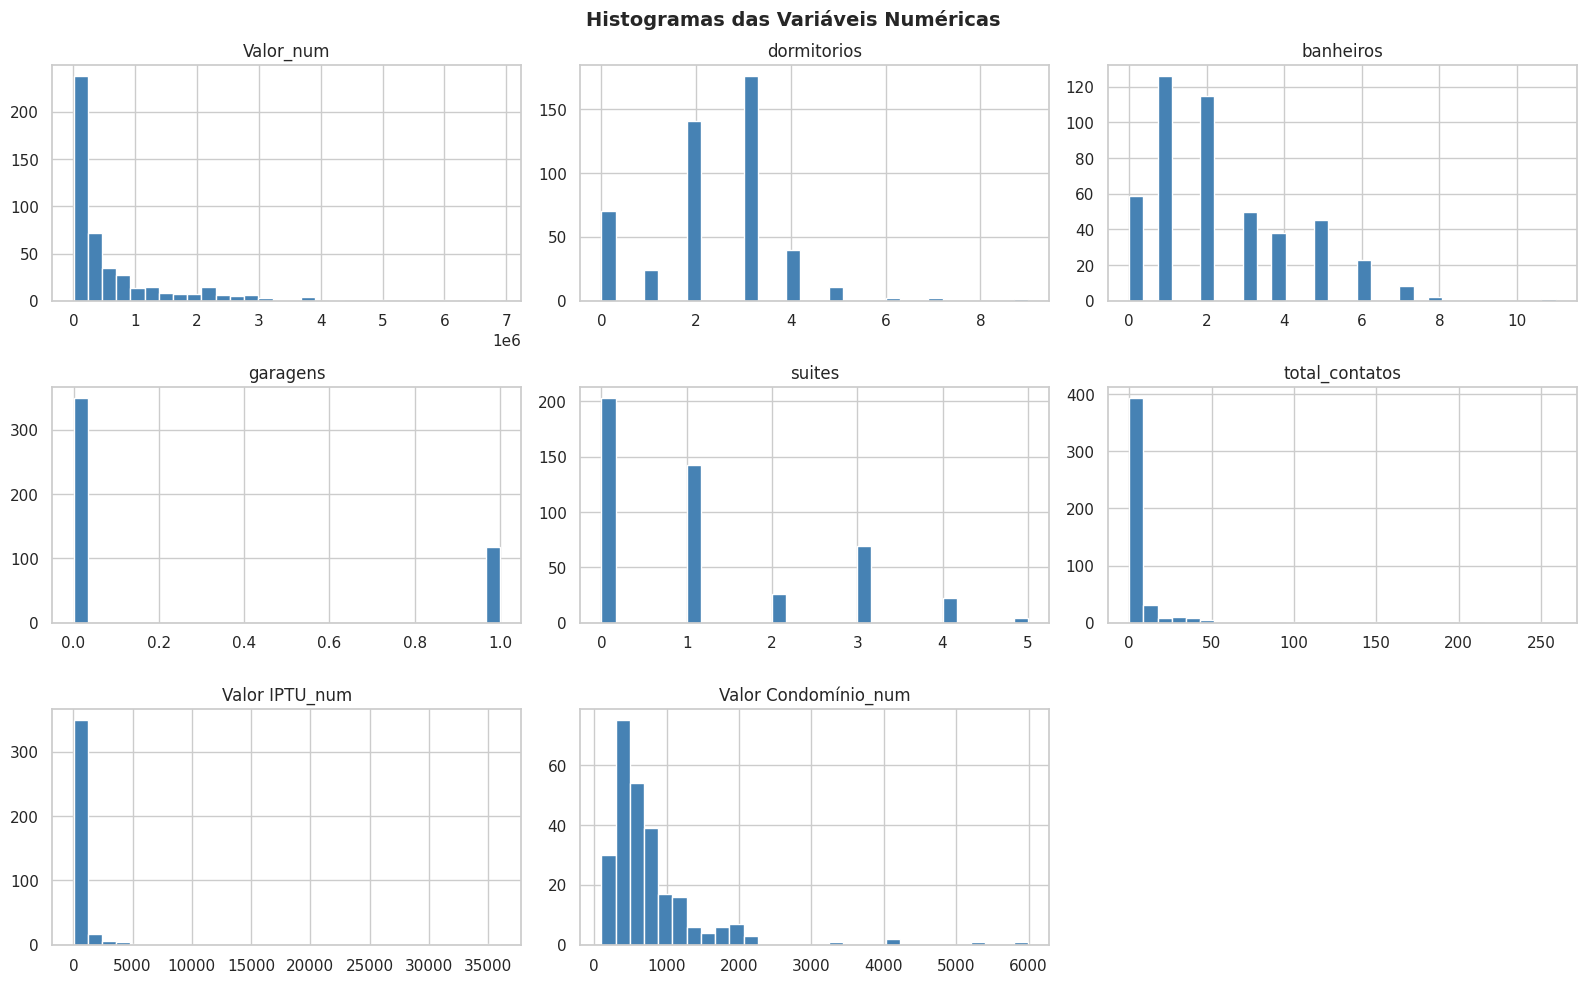

In [20]:
# ──────────────────────────────────────────────
# 5.1 Distribuição e histogramas das variáveis numéricas
# ──────────────────────────────────────────────
# Equivalente ao housing.hist() da Aula 06.
# Observamos a distribuição de cada variável para identificar assimetrias,
# outliers e a necessidade de transformações.

cols_hist = ['Valor_num', 'dormitorios', 'banheiros', 'garagens',
             'suites', 'total_contatos', 'Valor IPTU_num', 'Valor Condomínio_num']
cols_hist_existentes = [c for c in cols_hist if c in df_master.columns]

df_master[cols_hist_existentes].hist(bins=30, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Histogramas das Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

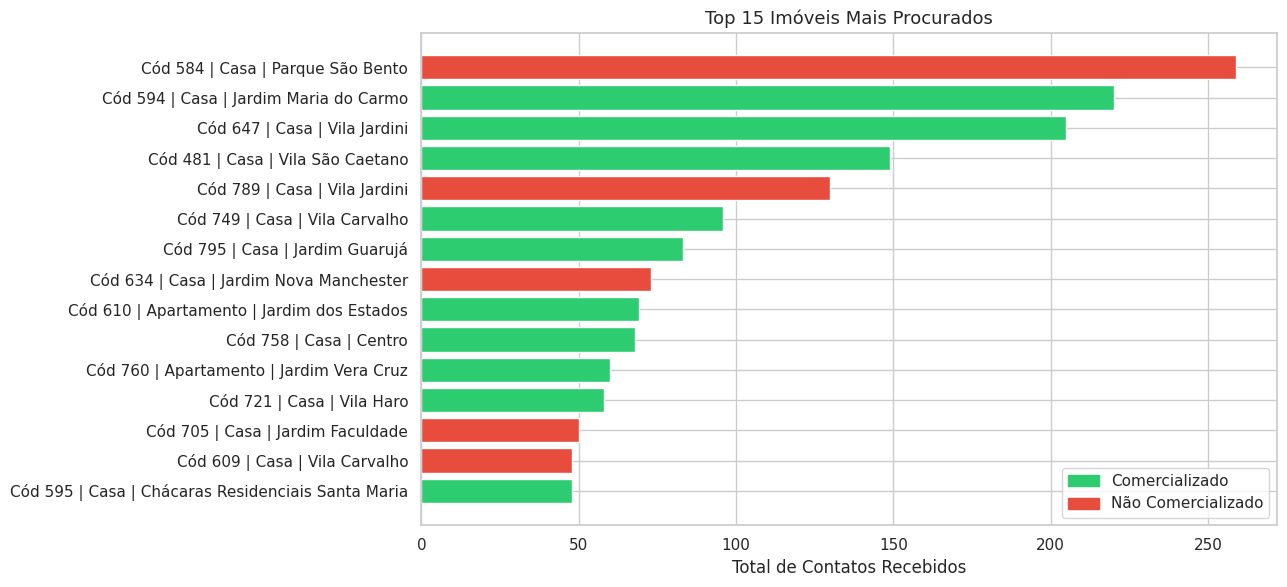

,Referência,tipo_simples,Bairro,Finalidade,Valor_num,total_contatos,comercializado
51,584,Casa,Parque São Bento,Locação,1500.0,259,0
1,594,Casa,Jardim Maria do Carmo,Locação,600.0,220,1
13,647,Casa,Vila Jardini,Locação,1100.0,205,1
60,481,Casa,Vila São Caetano,Locação,1700.0,149,1
4,789,Casa,Vila Jardini,Locação,990.0,130,0
9,749,Casa,Vila Carvalho,Locação,1100.0,96,1
64,795,Casa,Jardim Guarujá,Locação,1700.0,83,1
258,634,Casa,Jardim Nova Manchester,Venda,290000.0,73,0
19,610,Apartamento,Jardim dos Estados,Locação,1190.0,69,1
231,758,Casa,Centro,Venda,210000.0,68,1


In [21]:
# ──────────────────────────────────────────────
# 5.2 Imóveis mais procurados (Top 15)
# ──────────────────────────────────────────────
# Verde = foi comercializado (validação de que a demanda converte)
# Vermelho = alto interesse mas não comercializado (oportunidade)

top15 = (
    df_master[df_master['total_contatos'] > 0]
    .nlargest(15, 'total_contatos')
    [['Referência', 'tipo_simples', 'Bairro', 'Finalidade',
      'Valor_num', 'total_contatos', 'comercializado']]
)

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(
    top15.apply(lambda r: f"Cód {int(r['Referência'])} | {r['tipo_simples']} | {r['Bairro']}", axis=1),
    top15['total_contatos'],
    color=top15['comercializado'].map({1: '#2ecc71', 0: '#e74c3c'})
)
ax.set_xlabel('Total de Contatos Recebidos')
ax.set_title('Top 15 Imóveis Mais Procurados', fontsize=13)
ax.invert_yaxis()
ax.legend(handles=[Patch(color='#2ecc71', label='Comercializado'),
                   Patch(color='#e74c3c', label='Não Comercializado')])
plt.tight_layout()
plt.show()

display(top15)

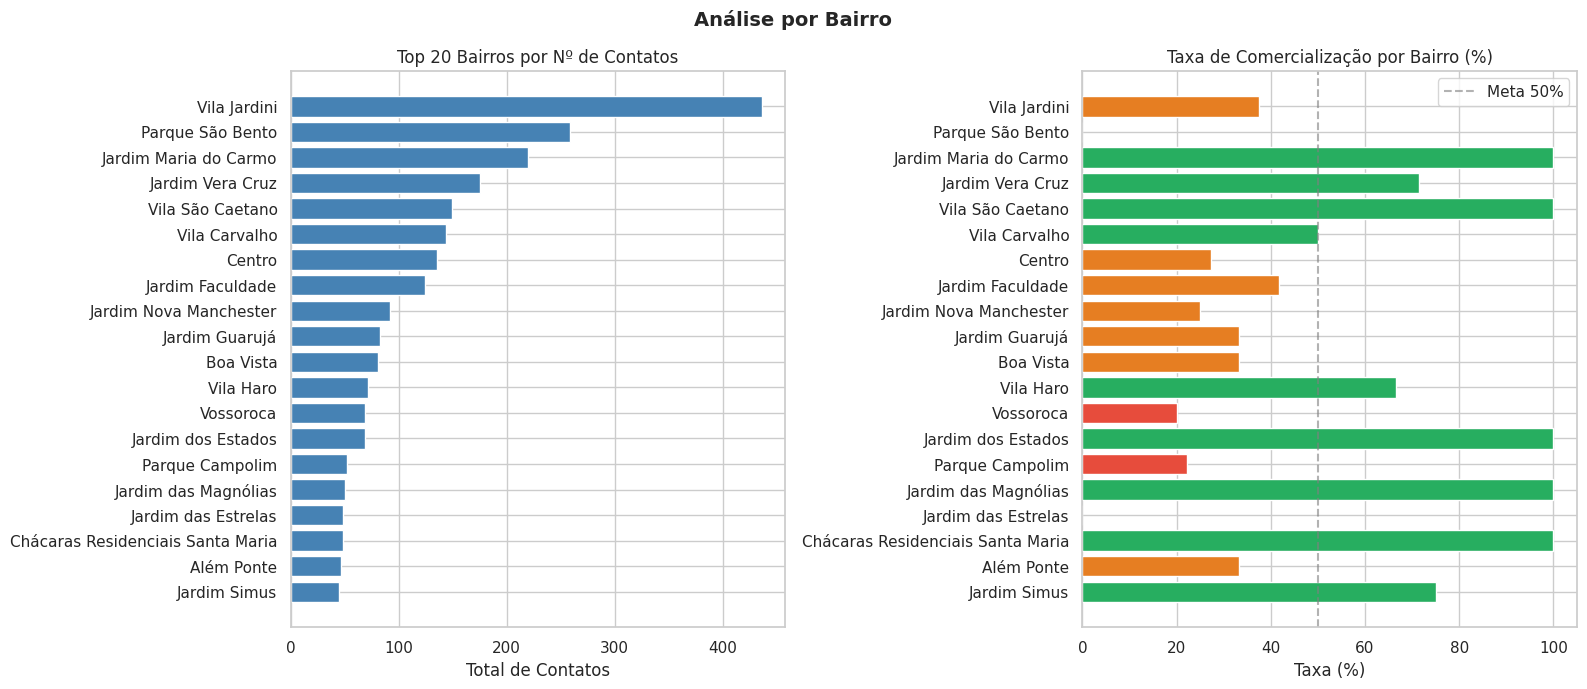


Tabela — Top 20 Bairros:


,Bairro,total_contatos,qtd_imoveis,taxa_comercializacao
0,Vila Jardini,436,7,0.375000
1,Parque São Bento,259,2,0.000000
2,Jardim Maria do Carmo,220,1,1.000000
3,Jardim Vera Cruz,175,7,0.714286
4,Vila São Caetano,149,1,1.000000
5,Vila Carvalho,144,2,0.500000
6,Centro,135,13,0.272727
7,Jardim Faculdade,124,7,0.416667
8,Jardim Nova Manchester,92,3,0.250000
9,Jardim Guarujá,83,3,0.333333


In [23]:
# ──────────────────────────────────────────────
# 5.3 Bairros — volume de procura e taxa de comercialização
# ──────────────────────────────────────────────
# Agrupamos por bairro para entender quais regiões têm mais demanda
# e quais convertem melhor (taxa de comercialização).

bairros = (
    df_master
    .groupby('Bairro', dropna=True)
    .agg(
        total_contatos      =('total_contatos',   'sum'),
        qtd_imoveis         =('Referência',        'count'),
        taxa_comercializacao=('comercializado',    'mean')
    )
    .sort_values('total_contatos', ascending=False)
    .reset_index()
)

top_bairros = bairros.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: volume bruto de contatos por bairro
axes[0].barh(top_bairros['Bairro'], top_bairros['total_contatos'], color='steelblue')
axes[0].set_title('Top 20 Bairros por Nº de Contatos', fontsize=12)
axes[0].set_xlabel('Total de Contatos')
axes[0].invert_yaxis()

# Gráfico 2: taxa de comercialização — cores indicam performance
# Verde ≥ 50%, Laranja 25–50%, Vermelho < 25%
cores = ['#27ae60' if v >= 0.5 else '#e67e22' if v >= 0.25 else '#e74c3c'
         for v in top_bairros['taxa_comercializacao']]
axes[1].barh(top_bairros['Bairro'], top_bairros['taxa_comercializacao'] * 100, color=cores)
axes[1].set_title('Taxa de Comercialização por Bairro (%)', fontsize=12)
axes[1].set_xlabel('Taxa (%)')
axes[1].invert_yaxis()
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.6, label='Meta 50%')
axes[1].legend()

plt.suptitle('Análise por Bairro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTabela — Top 20 Bairros:')
display(top_bairros)

Correlação com "comercializado" (variável-alvo):


,comercializado
comercializado,1.000000
total_contatos,0.246258
garagens,0.075236
dormitorios,-0.053466
banheiros,-0.104866
suites,-0.134795
Valor_num,-0.282325


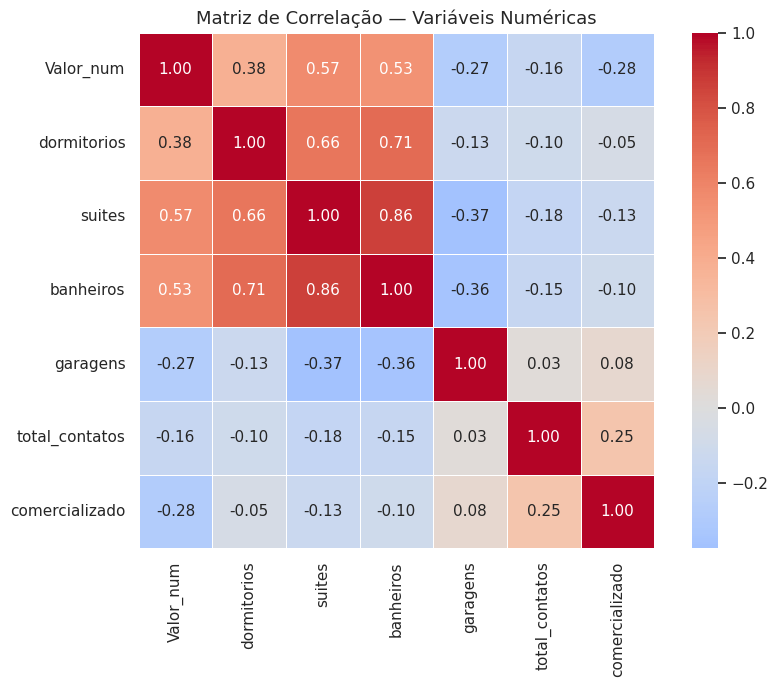

In [24]:
# ──────────────────────────────────────────────
# 5.4 Matriz de correlação
# ──────────────────────────────────────────────
# Equivalente ao corr_matrix da Aula 06.
# Mostra quais variáveis numéricas têm relação linear com a variável-alvo.
# Valores próximos de +1 ou -1 indicam correlação forte.

cols_corr = ['Valor_num', 'dormitorios', 'suites', 'banheiros', 'garagens',
             'total_contatos', 'comercializado']

corr_matrix = df_master[cols_corr].corr()

# Destacar a correlação com a variável-alvo
print('Correlação com "comercializado" (variável-alvo):')
display(corr_matrix['comercializado'].sort_values(ascending=False))

# Heatmap da matriz completa
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação — Variáveis Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

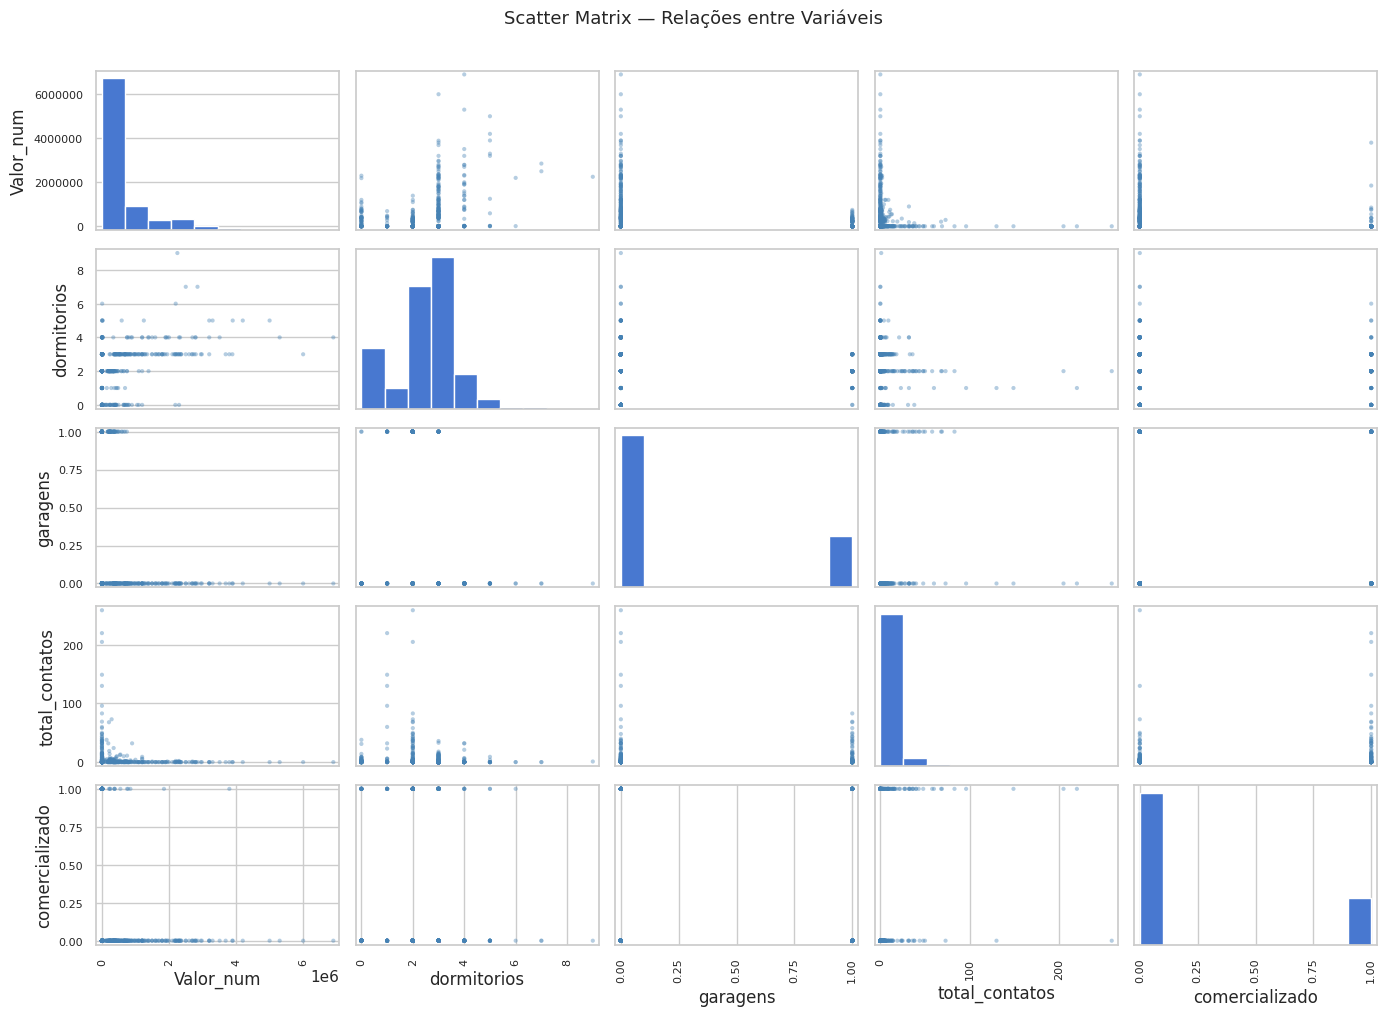

In [25]:
# ──────────────────────────────────────────────
# 5.5 Scatter matrix (matriz de dispersão)
# ──────────────────────────────────────────────
# Permite visualizar a relação entre pares de variáveis simultaneamente, além da distribuição de cada uma na diagonal.

attrs_scatter = ['Valor_num', 'dormitorios', 'garagens', 'total_contatos', 'comercializado']

scatter_matrix(
    df_master[attrs_scatter].dropna(),
    figsize=(14, 10),
    diagonal='hist',
    alpha=0.4,
    color='steelblue'
)
plt.suptitle('Scatter Matrix — Relações entre Variáveis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

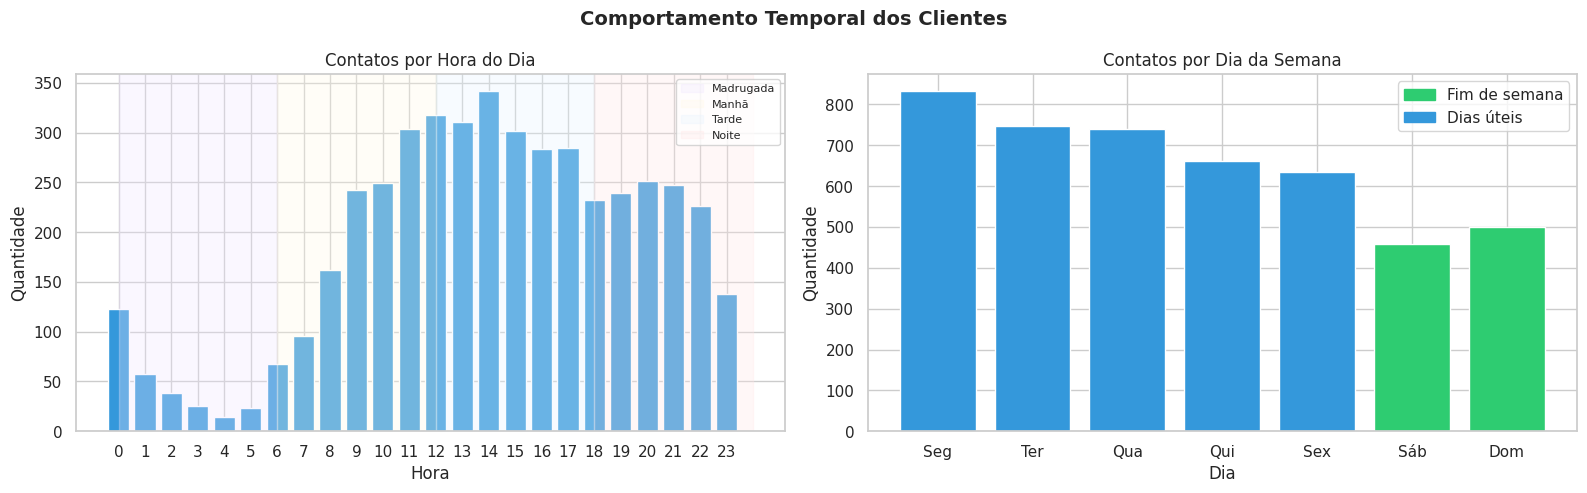

In [26]:
# ──────────────────────────────────────────────
# 5.6 Comportamento temporal dos clientes
# ──────────────────────────────────────────────
# Quando os clientes mais entram em contato?
# Essa análise orienta a equipe comercial sobre o melhor momento de atendimento.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: volume de contatos por hora do dia
hora_dist = df_contatos.dropna(subset=['hora'])['hora'].value_counts().sort_index()
axes[0].bar(hora_dist.index, hora_dist.values, color='#3498db', edgecolor='white')
axes[0].set_title('Contatos por Hora do Dia', fontsize=12)
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticks(range(0, 24))
# Fundo colorido por turno para facilitar leitura visual
for inicio, fim, cor, label in [(0, 6, '#f0e6ff', 'Madrugada'), (6, 12, '#fff9e6', 'Manhã'),
                                 (12, 18, '#e6f4ff', 'Tarde'),   (18, 24, '#ffe6e6', 'Noite')]:
    axes[0].axvspan(inicio, fim, alpha=0.3, color=cor, label=label)
axes[0].legend(fontsize=8)

# Gráfico 2: volume de contatos por dia da semana
dia_dist = (
    df_contatos.dropna(subset=['dia_semana'])['dia_semana']
    .value_counts().sort_index()
    .rename(index=dias_map)
)
axes[1].bar(dia_dist.index, dia_dist.values,
            color=['#2ecc71' if d in ['Sáb', 'Dom'] else '#3498db' for d in dia_dist.index],
            edgecolor='white')
axes[1].set_title('Contatos por Dia da Semana', fontsize=12)
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Quantidade')
axes[1].legend(handles=[Patch(color='#2ecc71', label='Fim de semana'),
                         Patch(color='#3498db', label='Dias úteis')])

plt.suptitle('Comportamento Temporal dos Clientes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

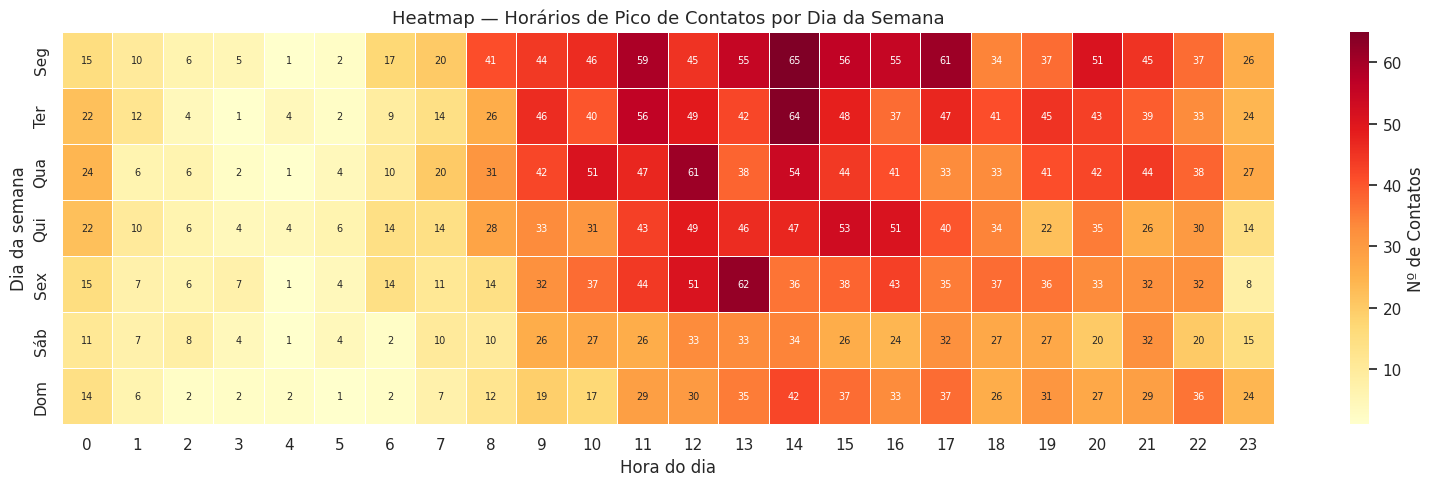

In [28]:
# ──────────────────────────────────────────────
# 5.7 Heatmap: hora × dia da semana
# ──────────────────────────────────────────────
# Combinação dos dois eixos temporais em um único gráfico.
# As células mais escuras revelam os horários de maior pico simultâneo — informação valiosa para escalar a equipe de atendimento.

pivot = (
    df_contatos
    .dropna(subset=['hora', 'dia_semana'])
    .groupby(['dia_semana', 'hora'])
    .size()
    .unstack(fill_value=0)
    .rename(index=dias_map)
)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': 'Nº de Contatos'},
            fmt='d', annot=True, annot_kws={'size': 7})
plt.title('Heatmap — Horários de Pico de Contatos por Dia da Semana', fontsize=13)
plt.xlabel('Hora do dia')
plt.ylabel('Dia da semana')
plt.tight_layout()
plt.show()

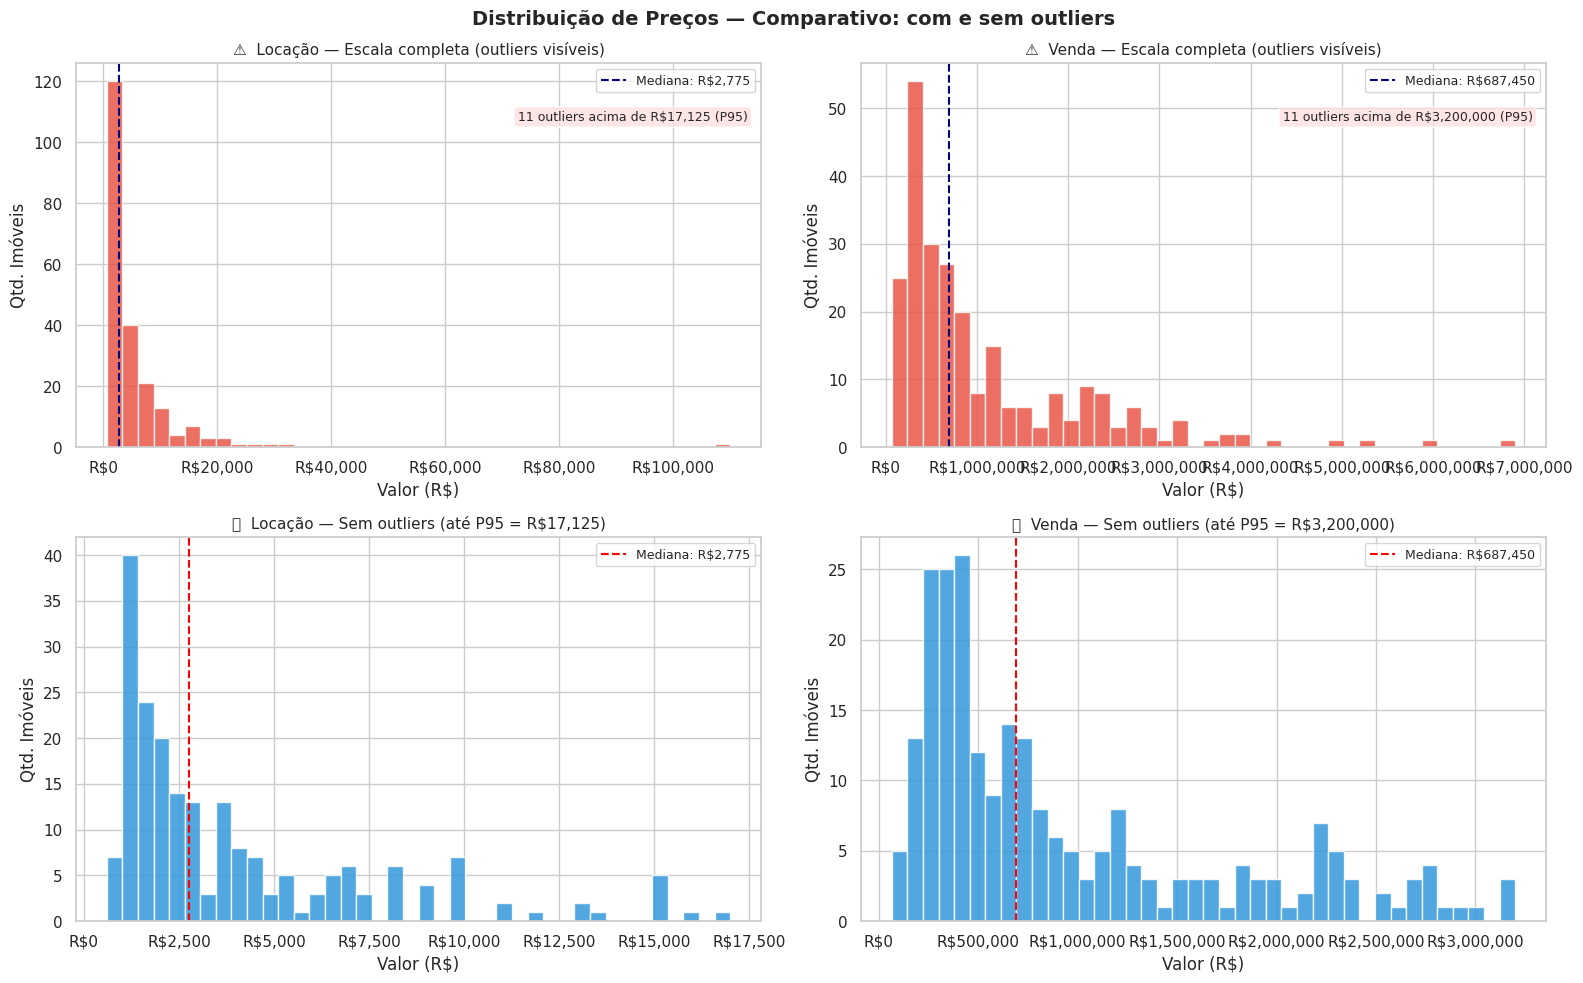


🔍 Outliers identificados (acima do P95 por finalidade):

  Locação — P95 = R$17,125  |  10 registros acima:


,Referência,tipo_simples,Bairro,Valor_num,dormitorios
218,<NA>,Comercial,Parque Campolim,110000.0,0
215,516,Comercial,Parque Campolim,32000.0,0
214,<NA>,Comercial,Vila Artura,28000.0,0
213,<NA>,Casa,Condomínio Fazenda Lago Azul,27000.0,4
212,<NA>,Comercial,Jardim São Carlos,25000.0,0
211,<NA>,Comercial,Iporanga,20474.0,0
210,305,Casa,Parque Reserva Fazenda Imperial,20000.0,0
209,<NA>,Apartamento,Parque Campolim,19900.0,5
208,<NA>,Comercial,Iporanga,18010.0,0
207,<NA>,Casa,Alphaville Nova Esplanada 3,18000.0,3



  Venda — P95 = R$3,200,000  |  10 registros acima:


,Referência,tipo_simples,Bairro,Valor_num,dormitorios
466,<NA>,Casa,Condomínio Fazenda Lago Azul,6900000.0,4
465,<NA>,Casa,Além Ponte,6000000.0,3
464,<NA>,Casa,Parque Reserva Fazenda Imperial,5300000.0,4
463,<NA>,Casa,Jardim Village Saint Charbel,5000000.0,5
462,<NA>,Casa,Alphaville Nova Esplanada,4200000.0,5
461,<NA>,Casa,Cyrela Landscape Esplanada,3900000.0,5
460,<NA>,Casa,Condomínio Fazenda Imperial,3890000.0,3
459,<NA>,Casa,Alphaville Nova Esplanada,3800000.0,3
458,<NA>,Casa,Parque Reserva Fazenda Imperial,3690000.0,3
457,<NA>,Casa,Parque Campolim,3510000.0,4


In [30]:
# ──────────────────────────────────────────────
# 5.8 Distribuição de preços por finalidade (com tratamento de outliers)
# ──────────────────────────────────────────────
# Estratégia de tratamento (igual à Aula 06 — cap de valores extremos):
#   1. Identificar e exibir os outliers
#   2. Definir limite superior pelo percentil 95 de cada finalidade
#   3. Plotar com a escala ajustada para revelar a distribuição real

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, finalidade in enumerate(['Locação', 'Venda']):
    subset = df_master[
        (df_master['Finalidade'] == finalidade) & df_master['Valor_num'].notna()
    ].copy()

    # ── Calcular limite superior pelo percentil 95
    # P95 remove os 5% mais caros (outliers) sem descartar dados do modelo —
    # apenas limitamos o eixo do gráfico para visualização.
    p95   = subset['Valor_num'].quantile(0.95)
    p99   = subset['Valor_num'].quantile(0.99)
    vmax  = subset['Valor_num'].max()
    mediana = subset['Valor_num'].median()

    n_outliers = (subset['Valor_num'] > p95).sum()

    # ── Gráfico 1 (linha de cima): distribuição COMPLETA — evidencia o problema
    ax_raw = axes[0][col_idx]
    ax_raw.hist(subset['Valor_num'], bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
    ax_raw.axvline(mediana, color='navy', linestyle='--',
                   label=f'Mediana: R${mediana:,.0f}')
    ax_raw.set_title(f'⚠️  {finalidade} — Escala completa (outliers visíveis)', fontsize=11)
    ax_raw.set_xlabel('Valor (R$)')
    ax_raw.set_ylabel('Qtd. Imóveis')
    ax_raw.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
    ax_raw.legend(fontsize=9)
    ax_raw.annotate(f'{n_outliers} outliers acima de R${p95:,.0f} (P95)',
                    xy=(0.98, 0.85), xycoords='axes fraction',
                    ha='right', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.8))

    # ── Gráfico 2 (linha de baixo): distribuição FILTRADA — revela o padrão real
    subset_filtrado = subset[subset['Valor_num'] <= p95]
    ax_filt = axes[1][col_idx]
    ax_filt.hist(subset_filtrado['Valor_num'], bins=40,
                 color='#3498db', edgecolor='white', alpha=0.85)
    ax_filt.axvline(mediana, color='red', linestyle='--',
                    label=f'Mediana: R${mediana:,.0f}')
    ax_filt.set_title(f'✅  {finalidade} — Sem outliers (até P95 = R${p95:,.0f})', fontsize=11)
    ax_filt.set_xlabel('Valor (R$)')
    ax_filt.set_ylabel('Qtd. Imóveis')
    ax_filt.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
    ax_filt.legend(fontsize=9)

plt.suptitle('Distribuição de Preços — Comparativo: com e sem outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Exibir os outliers identificados (útil para auditar os dados)
print('\n🔍 Outliers identificados (acima do P95 por finalidade):')
for finalidade in ['Locação', 'Venda']:
    subset = df_master[(df_master['Finalidade'] == finalidade) & df_master['Valor_num'].notna()]
    p95 = subset['Valor_num'].quantile(0.95)
    outliers = (
        subset[subset['Valor_num'] > p95]
        [['Referência', 'tipo_simples', 'Bairro', 'Valor_num', 'dormitorios']]
        .sort_values('Valor_num', ascending=False)
        .head(10)
    )
    print(f'\n  {finalidade} — P95 = R${p95:,.0f}  |  {len(outliers)} registros acima:')
    display(outliers)

---
## 6. Mapa Geográfico de Demanda por Bairro

Inspirado no mapa da Califórnia da **Aula 06**, plotamos a demanda geograficamente.
Usamos a API **Nominatim (OpenStreetMap)** para geocodificar os bairros de Sorocaba
e o `folium` para criar um mapa de calor interativo.

In [31]:
# ──────────────────────────────────────────────
# 6.1 Geocodificação dos bairros via Nominatim
# ──────────────────────────────────────────────
# Nominatim é a API de geocodificação do OpenStreetMap — gratuita,
# sem necessidade de chave de API, mas com limite de 1 requisição/segundo.
# Geocodificamos apenas os bairros únicos (economiza chamadas de API).

_geocache = {}  # cache em memória para não repetir a mesma busca

def geocodificar_bairro(bairro, cidade='Sorocaba', estado='SP'):
    """Retorna (lat, lon) para um bairro de Sorocaba via Nominatim.
    Usa cache para evitar requisições repetidas ao longo do notebook."""
    chave = bairro.strip().lower()
    if chave in _geocache:
        return _geocache[chave]
    query = quote(f'{bairro}, {cidade}, {estado}, Brasil')
    url = f'https://nominatim.openstreetmap.org/search?q={query}&format=json&limit=1'
    try:
        r = requests.get(url, headers={'User-Agent': 'TrabalhoAcademico/1.0'}, timeout=8)
        data = r.json()
        if data:
            lat, lon = float(data[0]['lat']), float(data[0]['lon'])
            _geocache[chave] = (lat, lon)
            time.sleep(1.1)  # respeitar o limite de 1 req/s da API
            return lat, lon
    except Exception:
        pass
    _geocache[chave] = (None, None)
    return None, None

# Processar todos os bairros únicos do catálogo
bairros_unicos = df_master['Bairro'].dropna().unique()
print(f'Geocodificando {len(bairros_unicos)} bairros únicos... (pode levar alguns minutos)')

coords_bairro = {}
for i, bairro in enumerate(bairros_unicos):
    coords_bairro[bairro] = geocodificar_bairro(bairro)
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(bairros_unicos)} bairros processados...')

# Adicionar coordenadas ao df_master
df_master['lat'] = df_master['Bairro'].map(lambda b: coords_bairro.get(b, (None, None))[0])
df_master['lon'] = df_master['Bairro'].map(lambda b: coords_bairro.get(b, (None, None))[1])

geo_ok = df_master['lat'].notna().sum()
print(f'\n✅ Geocodificação concluída: {geo_ok}/{len(df_master)} imóveis com coordenadas')

Geocodificando 165 bairros únicos... (pode levar alguns minutos)
  10/165 bairros processados...
  20/165 bairros processados...
  30/165 bairros processados...
  40/165 bairros processados...
  50/165 bairros processados...
  60/165 bairros processados...
  70/165 bairros processados...
  80/165 bairros processados...
  90/165 bairros processados...
  100/165 bairros processados...
  110/165 bairros processados...
  120/165 bairros processados...
  130/165 bairros processados...
  140/165 bairros processados...
  150/165 bairros processados...
  160/165 bairros processados...

✅ Geocodificação concluída: 321/467 imóveis com coordenadas


In [32]:
# ──────────────────────────────────────────────
# 6.2 Mapa de calor interativo com folium
# ──────────────────────────────────────────────
# Mapa de calor (HeatMap): intensidade = total de contatos por bairro.
# Marcadores circulares: tamanho proporcional à demanda.
# Clique nos marcadores para ver o nome do bairro e total de contatos.

df_geo = df_master[df_master['lat'].notna() & (df_master['total_contatos'] > 0)].copy()

# Centro do mapa: Sorocaba - SP
mapa = folium.Map(location=[-23.5015, -47.4526], zoom_start=13, tiles='CartoDB positron')

# Camada de calor — cada imóvel contribui com peso = total_contatos
heat_data = [[row['lat'], row['lon'], row['total_contatos']]
             for _, row in df_geo.iterrows()]
HeatMap(heat_data, radius=25, blur=15, max_zoom=14).add_to(mapa)

# Marcadores agrupados por bairro
resumo_geo = (
    df_geo.groupby('Bairro')
    .agg(contatos=('total_contatos', 'sum'), lat=('lat', 'first'), lon=('lon', 'first'))
    .reset_index()
)
for _, row in resumo_geo.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=min(20, 3 + row['contatos'] * 0.3),
        color='#e74c3c', fill=True, fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{row['Bairro']}</b><br>Contatos: {int(row['contatos'])}", max_width=200)
    ).add_to(mapa)

mapa.save('mapa_demanda_imoveis.html')
print('✅ Mapa salvo em mapa_demanda_imoveis.html')
mapa  # exibe inline no Colab

✅ Mapa salvo em mapa_demanda_imoveis.html


---
## 7. Clusterização K-Means

Agrupamos os imóveis em perfis distintos baseados em suas características numéricas.
Seguindo a **Aula 11**, utilizamos dois métodos para determinar o K ideal:
- **Método do Cotovelo (Elbow)** — minimiza a inércia intracluster
- **Silhouette Score** — mede a qualidade da separação entre clusters

In [33]:
# ──────────────────────────────────────────────
# 7.1 Preparar dados para clusterização
# ──────────────────────────────────────────────
# Selecionamos apenas variáveis numéricas relevantes.
# Pipeline de pré-processamento: imputação de nulos → normalização (StandardScaler).
# A normalização é essencial para o K-Means, pois ele usa distância euclidiana
# e variáveis em escalas diferentes distorceriam os clusters.

features_cluster = ['Valor_num', 'dormitorios', 'banheiros', 'garagens',
                    'suites', 'total_contatos']

# Pipeline de pré-processamento exclusivo para clusterização
pipeline_cluster = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # preenche nulos com mediana
    ('scaler',  StandardScaler())                    # normaliza para média=0, desvio=1
])

X_cluster = pipeline_cluster.fit_transform(df_master[features_cluster])
print(f'Matriz para clusterização: {X_cluster.shape}')

Matriz para clusterização: (467, 6)


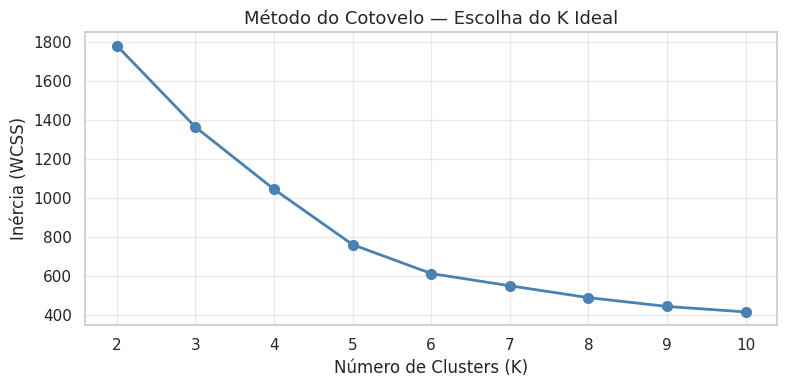

Dica: o cotovelo é o ponto onde a curva "dobra" — K ideal está nesse ponto.


In [34]:
# ──────────────────────────────────────────────
# 7.2 Método do Cotovelo (Elbow) — Aula 11
# ──────────────────────────────────────────────
# Treinamos K-Means para diferentes valores de K e plotamos a inércia.
# A inércia mede a soma das distâncias quadradas de cada ponto ao seu centroide.
# O "cotovelo" da curva indica o K a partir do qual adicionar mais clusters
# traz ganho marginal decrescente.

inertias = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(ks, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.title('Método do Cotovelo — Escolha do K Ideal', fontsize=13)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(ks)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()
print('Dica: o cotovelo é o ponto onde a curva "dobra" — K ideal está nesse ponto.')

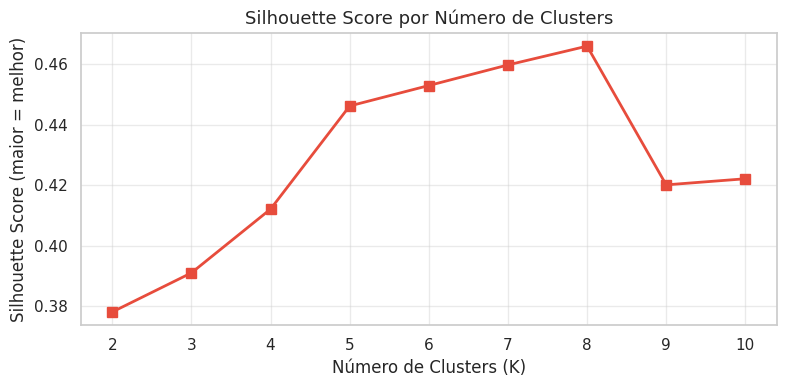


Comparativo — Inércia vs Silhouette Score:


,K,Inércia,Silhouette Score
0,2,1781.318798,0.3780
1,3,1363.670019,0.3910
2,4,1044.523567,0.4121
3,5,760.468434,0.4462
4,6,612.065124,0.4530
5,7,549.157309,0.4598
6,8,488.356648,0.4661
7,9,443.226176,0.4201
8,10,414.972789,0.4221


In [35]:
# ──────────────────────────────────────────────
# 7.3 Silhouette Score — validação do K (Aula 11)
# ──────────────────────────────────────────────
# O Silhouette Score complementa o cotovelo.
# Mede o quão bem cada ponto está no seu próprio cluster em relação
# aos clusters vizinhos. Varia de -1 a +1; quanto mais próximo de 1, melhor.

silhouette_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(ks, silhouette_scores, 's-', color='#e74c3c', linewidth=2, markersize=7)
plt.title('Silhouette Score por Número de Clusters', fontsize=13)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score (maior = melhor)')
plt.xticks(ks)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Tabela comparativa dos dois critérios
print('\nComparativo — Inércia vs Silhouette Score:')
display(pd.DataFrame({'K': list(ks), 'Inércia': inertias,
                      'Silhouette Score': [round(s, 4) for s in silhouette_scores]}))

In [37]:
# ──────────────────────────────────────────────
# 7.4 Aplicar K-Means com K escolhido
# ──────────────────────────────────────────────
# Ajuste K_IDEAL com base nos gráficos das células anteriores.
# Critério: cotovelo claro no gráfico de inércia E pico no Silhouette Score.

K_IDEAL = 4  # ← ajuste conforme os gráficos

kmeans = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
df_master['cluster'] = kmeans.fit_predict(X_cluster)

# Perfil médio de cada cluster — permite nomear os grupos de forma intuitiva
# Ex: Cluster 0 = "Imóveis econômicos de alta demanda"
#     Cluster 1 = "Imóveis premium de baixa demanda"
perfil_clusters = (
    df_master.groupby('cluster')[features_cluster + ['comercializado']]
    .mean().round(2)
)
print(f'Perfil médio por Cluster (K={K_IDEAL}):')
display(perfil_clusters)

Perfil médio por Cluster (K=4):


,Valor_num,dormitorios,banheiros,garagens,suites,total_contatos,comercializado
cluster,,,,,,,
0,1165.00,1.33,1.00,0.0,0.17,176.50,0.67
1,137836.09,2.03,1.22,1.0,0.27,8.33,0.29
2,343648.86,1.83,1.63,0.0,0.57,5.04,0.24
3,1555700.00,3.60,4.97,0.0,2.96,0.70,0.14


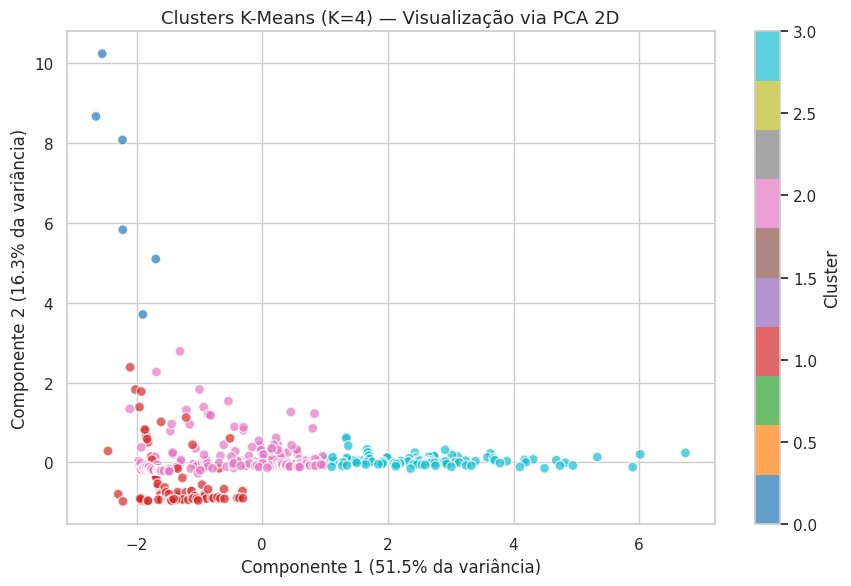

Variância total explicada pelos 2 componentes: 67.7%


In [38]:
# ──────────────────────────────────────────────
# 7.5 Visualizar clusters com PCA (2D) — Aula 10
# ──────────────────────────────────────────────
# Como temos 6 dimensões, usamos PCA para reduzir para 2 e visualizar.
# PCA (Análise de Componentes Principais) encontra os eixos de maior variância,
# preservando ao máximo a estrutura dos dados em menos dimensões.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_master['cluster'], cmap='tab10',
                      alpha=0.7, edgecolors='white', s=50)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Clusters K-Means (K={K_IDEAL}) — Visualização via PCA 2D', fontsize=13)
plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]:.1%} da variância)')
plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]:.1%} da variância)')
plt.tight_layout()
plt.show()
print(f'Variância total explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.1%}')

In [39]:
# ──────────────────────────────────────────────
# 7.6 Interpretação dos clusters
# ──────────────────────────────────────────────
# Cruzamos os clusters com variáveis categóricas para entender
# o perfil de cada grupo e nomear os clusters de forma descritiva.

print('Finalidade por cluster:')
display(pd.crosstab(df_master['cluster'], df_master['Finalidade'],
                    normalize='index').round(2))

print('\nTipo de imóvel por cluster (top 3):')
for c in range(K_IDEAL):
    top = df_master[df_master['cluster'] == c]['tipo_simples'].value_counts().head(3)
    print(f'  Cluster {c}: {dict(top)}')

print('\nBairros mais frequentes por cluster (top 3):')
for c in range(K_IDEAL):
    top = df_master[df_master['cluster'] == c]['Bairro'].value_counts().head(3)
    print(f'  Cluster {c}: {dict(top)}')

Finalidade por cluster:


Finalidade,Locação,Venda
cluster,,
0,1.00,0.00
1,0.59,0.41
2,0.45,0.55
3,0.32,0.68



Tipo de imóvel por cluster (top 3):
  Cluster 0: {'Casa': np.int64(6)}
  Cluster 1: {'Apartamento': np.int64(82), 'Casa': np.int64(34), 'Comercial': np.int64(2)}
  Cluster 2: {'Casa': np.int64(103), 'Apartamento': np.int64(51), 'Terreno/Lote': np.int64(34)}
  Cluster 3: {'Casa': np.int64(91), 'Apartamento': np.int64(25), 'Outro': np.int64(2)}

Bairros mais frequentes por cluster (top 3):
  Cluster 0: {'Vila Jardini': np.int64(2), 'Jardim Maria do Carmo': np.int64(1), 'Vila Carvalho': np.int64(1)}
  Cluster 1: {'Parque Campolim': np.int64(10), 'Jardim São Carlos': np.int64(6), 'Vila Hortência': np.int64(5)}
  Cluster 2: {'Parque Campolim': np.int64(26), 'Centro': np.int64(15), 'Jardim Vera Cruz': np.int64(5)}
  Cluster 3: {'Parque Campolim': np.int64(18), 'Alphaville Nova Esplanada': np.int64(11), 'Parque Reserva Fazenda Imperial': np.int64(5)}


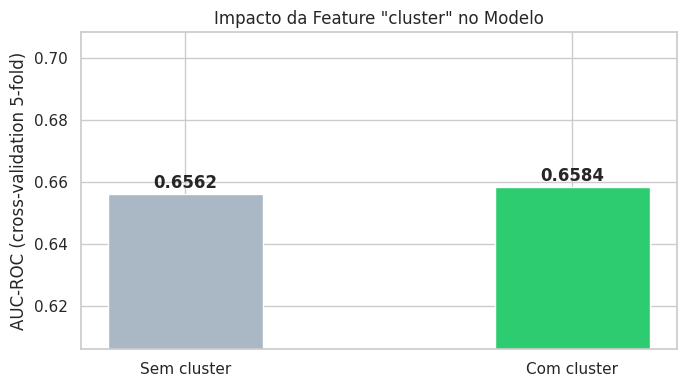

Sem cluster : AUC = 0.6562
Com cluster : AUC = 0.6584
Variacao    : +0.0022  (+0.22 pontos percentuais)

A feature cluster tem impacto neutro -- mantida por valor interpretativo.


In [58]:
# ──────────────────────────────────────────────
# 7.7 Impacto do cluster como feature no modelo
# ──────────────────────────────────────────────
# A clusterizacao gerou a feature 'cluster'. Mas ela realmente ajuda o modelo?
# Medimos o impacto comparando AUC-ROC com e sem ela.
# Esta e a forma correta de justificar uma decisao de feature engineering.

from sklearn.linear_model import LogisticRegression as LR_t
from sklearn.pipeline import Pipeline as Pipe_t
from sklearn.compose import ColumnTransformer as CT_t
from sklearn.preprocessing import StandardScaler as SS_t, OneHotEncoder as OHE_t
from sklearn.impute import SimpleImputer as SI_t
from sklearn.model_selection import cross_val_score, StratifiedKFold

fn_base = ['Valor_num', 'dormitorios', 'suites', 'banheiros', 'garagens', 'total_contatos']
fc_base = ['Finalidade', 'tipo_simples']
df_t    = df_master[df_master['Disponibilidade'].notna()].copy()
y_t     = df_t['comercializado']
cv_t    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def montar_pipe_t(fn, fc):
    prep = CT_t([
        ('num', Pipe_t([('imp', SI_t(strategy='median')), ('sc', SS_t())]), fn),
        ('cat', Pipe_t([('imp', SI_t(strategy='most_frequent')),
                         ('ohe', OHE_t(handle_unknown='ignore', drop='first',
                                        sparse_output=False))]), fc)
    ])
    return Pipe_t([('prep', prep),
                    ('clf', LR_t(max_iter=1000, random_state=42, class_weight='balanced'))])

pipe_sem = montar_pipe_t(fn_base, fc_base)
auc_sem  = cross_val_score(pipe_sem, df_t[fn_base + fc_base],
                            y_t, cv=cv_t, scoring='roc_auc').mean()

fn_com  = fn_base + ['cluster']
pipe_com = montar_pipe_t(fn_com, fc_base)
auc_com  = cross_val_score(pipe_com, df_t[fn_com + fc_base],
                            y_t, cv=cv_t, scoring='roc_auc').mean()

fig, ax = plt.subplots(figsize=(7, 4))
cores_comp = ['#aab7c4', '#2ecc71' if auc_com >= auc_sem else '#e74c3c']
bars = ax.bar(['Sem cluster', 'Com cluster'], [auc_sem, auc_com],
              color=cores_comp, edgecolor='white', width=0.4)
ax.set_ylim(max(0, min(auc_sem, auc_com) - 0.05), min(1, max(auc_sem, auc_com) + 0.05))
ax.set_ylabel('AUC-ROC (cross-validation 5-fold)')
ax.set_title('Impacto da Feature "cluster" no Modelo', fontsize=12)
for bar, val in zip(bars, [auc_sem, auc_com]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

delta = auc_com - auc_sem
sinal = '+' if delta >= 0 else ''
print(f'Sem cluster : AUC = {auc_sem:.4f}')
print(f'Com cluster : AUC = {auc_com:.4f}')
print(f'Variacao    : {sinal}{delta:.4f}  ({sinal}{delta*100:.2f} pontos percentuais)')
print()
if delta > 0.005:
    print('A feature cluster AGREGA valor ao modelo -- sera mantida.')
elif delta < -0.005:
    print('A feature cluster PREJUDICA o modelo -- avaliar remocao.')
else:
    print('A feature cluster tem impacto neutro -- mantida por valor interpretativo.')


---
## 8. Pipeline de Pré-processamento (`ColumnTransformer`)

Seguindo a **Aula 06**, construímos um `Pipeline` com `ColumnTransformer`
que trata automaticamente variáveis numéricas (imputação + escalonamento)
e categóricas (imputação + OneHotEncoding) de forma integrada e reutilizável.

Vantagens do Pipeline:
- Evita **data leakage** (vazamento de dados do teste para o treino)
- Facilita a aplicação do mesmo pré-processamento em novos dados
- Compatível com `GridSearchCV` e `RandomizedSearchCV`

In [40]:
# ──────────────────────────────────────────────
# 8.1 Separar features e variável-alvo
# ──────────────────────────────────────────────
# Usamos apenas imóveis com Disponibilidade explicitamente definida
# (NaN = imóvel ativo sem desfecho, excluído do treino por enquanto).

df_model = df_master[df_master['Disponibilidade'].notna()].copy()

# Features numéricas que entram no modelo
FEATURES_NUM = ['Valor_num', 'Valor IPTU_num', 'Valor Condomínio_num',
                'dormitorios', 'suites', 'banheiros', 'garagens',
                'total_contatos', 'cluster']

# Features categóricas — serão codificadas com OneHotEncoder
FEATURES_CAT = ['Finalidade', 'tipo_simples']

TODAS_FEATURES = FEATURES_NUM + FEATURES_CAT

# Garantir que todas as features existem (segurança)
FEATURES_NUM = [f for f in FEATURES_NUM if f in df_model.columns]
FEATURES_CAT = [f for f in FEATURES_CAT if f in df_model.columns]
TODAS_FEATURES = FEATURES_NUM + FEATURES_CAT

X = df_model[TODAS_FEATURES].copy()
y = df_model['comercializado'].copy()

print(f'Dataset de modelagem: {X.shape[0]} amostras × {X.shape[1]} features')
print(f'Variável-alvo: {y.value_counts().to_dict()}')
display(X.head(3))

Dataset de modelagem: 237 amostras × 11 features
Variável-alvo: {0: 128, 1: 109}


,Valor_num,Valor IPTU_num,Valor Condomínio_num,dormitorios,suites,banheiros,garagens,total_contatos,cluster,Finalidade,tipo_simples
1,600.0,25.0,NaN,1,0,1,0,220,0,Locação,Casa
2,750.0,50.0,220.0,2,0,1,1,0,1,Locação,Apartamento
3,900.0,240.0,329.0,2,0,1,1,27,1,Locação,Apartamento


In [41]:
# ──────────────────────────────────────────────
# 8.2 Divisão estratificada treino/teste — Aula 06
# ──────────────────────────────────────────────
# Usamos stratify=y para garantir que a proporção de imóveis
# comercializados seja a mesma no treino e no teste.
# Isso é especialmente importante quando as classes são desbalanceadas.
# (Equivalente ao StratifiedShuffleSplit da Aula 06)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 80% treino, 20% teste
    random_state=42,   # semente para reprodutibilidade
    stratify=y         # mantém proporção das classes
)

print(f'Treino : {X_train.shape[0]} amostras | Comercializados: {y_train.mean():.1%}')
print(f'Teste  : {X_test.shape[0]}  amostras | Comercializados: {y_test.mean():.1%}')

Treino : 189 amostras | Comercializados: 46.0%
Teste  : 48  amostras | Comercializados: 45.8%


In [42]:
# ──────────────────────────────────────────────
# 8.3 Construir o Pipeline de pré-processamento — Aula 06
# ──────────────────────────────────────────────
# Pipeline numérico:
#   1. SimpleImputer(median) → preenche nulos com a mediana da coluna
#   2. StandardScaler        → normaliza (média=0, desvio=1)
#
# Pipeline categórico:
#   1. SimpleImputer(most_frequent) → preenche nulos com o valor mais comum
#   2. OneHotEncoder(handle_unknown='ignore') → cria colunas binárias por categoria
#      handle_unknown='ignore': se aparecer uma categoria nova no teste, ignora
#      drop='first': remove uma coluna por variável para evitar multicolinearidade
#
# ColumnTransformer: aplica cada pipeline às colunas correspondentes e une tudo.

pipeline_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

pipeline_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', pipeline_num, FEATURES_NUM),   # aplica pipeline_num nas colunas numéricas
    ('cat', pipeline_cat, FEATURES_CAT)    # aplica pipeline_cat nas colunas categóricas
])

# Exibir estrutura do pré-processador (igual ao set_config(display='diagram') da Aula 06)
from sklearn import set_config
set_config(display='diagram')
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Valor_num', 'Valor IPTU_num',
                                  'Valor Condomínio_num', 'dormitorios',
                                  'suites', 'banheiros', 'garagens',
                                  'total_contatos', 'cluster']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Finalidade', 'tipo_simples'])])

---
## 9. Modelagem — Regressão Logística

A **Regressão Logística** é o modelo principal deste trabalho.
Ela estima a **probabilidade** P(imóvel ser comercializado | características),
usando a função sigmoide para transformar a saída linear em uma probabilidade entre 0 e 1.

O Pipeline completo integra o pré-processamento + o modelo em uma única estrutura,
exatamente como mostrado na **Aula 06** com `make_pipeline(preprocessing, LinearRegression())`.

In [43]:
# ──────────────────────────────────────────────
# 9.1 Pipeline completo: pré-processamento + Regressão Logística
# ──────────────────────────────────────────────
# class_weight='balanced': ajusta automaticamente os pesos das classes
# para compensar o desbalanceamento (mais imóveis não comercializados que comercializados).
# max_iter=1000: garante convergência do algoritmo de otimização.

pipeline_lr = Pipeline([
    ('preprocessor',  preprocessor),
    ('classifier',    LogisticRegression(
                          max_iter=1000,
                          random_state=42,
                          class_weight='balanced'  # lida com desbalanceamento de classes
                      ))
])

# Treinar apenas no conjunto de treino (nunca no teste!)
pipeline_lr.fit(X_train, y_train)

# Predições no conjunto de teste
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]  # probabilidade da classe 1

print('=== Regressão Logística ===')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Não Comercializado', 'Comercializado']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Regressão Logística ===
                    precision    recall  f1-score   support

Não Comercializado       0.82      0.54      0.65        26
    Comercializado       0.61      0.86      0.72        22

          accuracy                           0.69        48
         macro avg       0.72      0.70      0.68        48
      weighted avg       0.73      0.69      0.68        48

AUC-ROC: 0.7316


Regressão Logística — AUC-ROC por fold (validação cruzada 5-fold):
  Fold 1: 0.6443
  Fold 2: 0.7591
  Fold 3: 0.5361
  Fold 4: 0.5806
  Fold 5: 0.5706
  Média: 0.6181 (±0.0787)

Matriz de Confusão — Conjunto de Treino (via Cross-Validation):


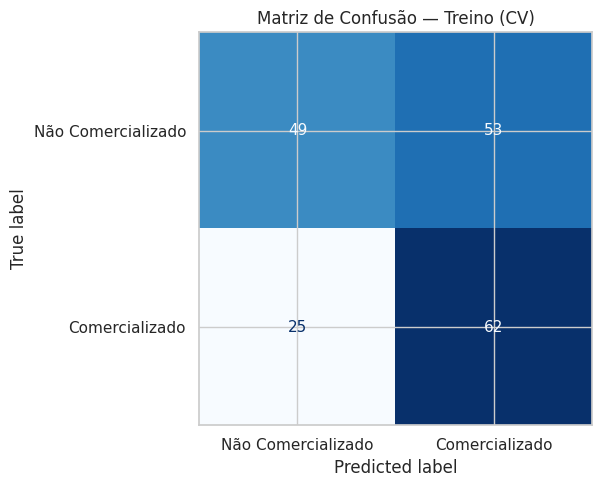

In [44]:
# ──────────────────────────────────────────────
# 9.2 Validação cruzada — Aula 05/06
# ──────────────────────────────────────────────
# A validação cruzada garante que o resultado não depende de um split específico.
# Dividimos os dados em 5 "dobras" (folds): treinamos em 4 e testamos em 1,
# rotacionando até que todos os dados tenham sido usados como teste.
# O resultado final é a média dos 5 AUCs.

# cross_val_predict: gera predições para todos os dados de treino via CV
# (útil para calcular métricas sobre o conjunto de treino inteiro)
y_train_pred_cv = cross_val_predict(
    pipeline_lr, X_train, y_train, cv=5
)

# cross_val_score: calcula AUC-ROC em cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(pipeline_lr, X_train, y_train,
                             cv=cv, scoring='roc_auc')

print('Regressão Logística — AUC-ROC por fold (validação cruzada 5-fold):')
for i, s in enumerate(scores_lr, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Média: {scores_lr.mean():.4f} (±{scores_lr.std():.4f})')

# Matriz de confusão no treino (via CV) — Aula 05
print('\nMatriz de Confusão — Conjunto de Treino (via Cross-Validation):')
cm_train = confusion_matrix(y_train, y_train_pred_cv)
disp = ConfusionMatrixDisplay(cm_train, display_labels=['Não Comercializado', 'Comercializado'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — Treino (CV)', fontsize=12)
plt.tight_layout()
plt.show()

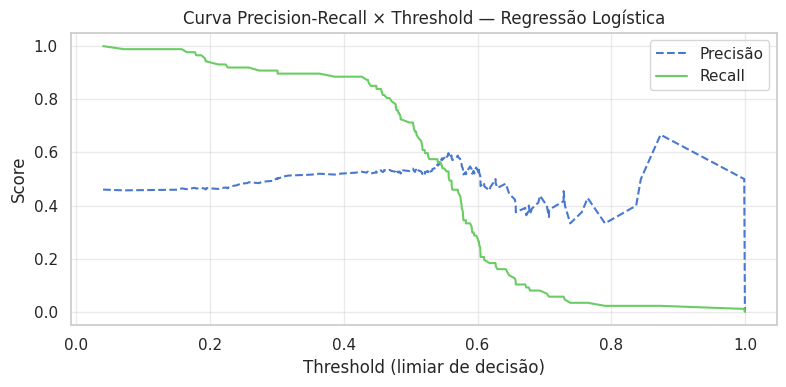

Dica: ajustar o threshold permite priorizar Precisão ou Recall conforme a necessidade de negócio.
Ex: threshold alto → modelo só prevê "comercializado" quando tem alta certeza (mais Precisão, menos Recall)


In [45]:
# ──────────────────────────────────────────────
# 9.3 Curva Precision-Recall — Aula 05
# ──────────────────────────────────────────────
# A curva Precision-Recall mostra o trade-off entre:
#   Precisão: dos que o modelo previu "vai comercializar", quantos realmente venderam?
#   Recall: dos que realmente comercializaram, quantos o modelo identificou?
# Útil quando as classes são desbalanceadas (AUC-PR é mais informativa que AUC-ROC nesses casos).

y_scores_cv = cross_val_predict(pipeline_lr, X_train, y_train,
                                 cv=5, method='predict_proba')[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores_cv)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precisão')
plt.plot(thresholds, recalls[:-1],    'g-',  label='Recall')
plt.xlabel('Threshold (limiar de decisão)')
plt.ylabel('Score')
plt.title('Curva Precision-Recall × Threshold — Regressão Logística', fontsize=12)
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print('Dica: ajustar o threshold permite priorizar Precisão ou Recall conforme a necessidade de negócio.')
print('Ex: threshold alto → modelo só prevê "comercializado" quando tem alta certeza (mais Precisão, menos Recall)')

In [46]:
# ──────────────────────────────────────────────
# 9.4 Comparativo com Random Forest e Gradient Boosting
# ──────────────────────────────────────────────
# Treinamos outros dois modelos para comparar com a Regressão Logística.
# Todos usam o mesmo preprocessor, garantindo comparação justa.

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=200, random_state=42,
                                             class_weight='balanced'))
])

pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   GradientBoostingClassifier(n_estimators=200, random_state=42))
])

pipeline_rf.fit(X_train, y_train)
pipeline_gb.fit(X_train, y_train)

y_pred_rf, y_prob_rf = pipeline_rf.predict(X_test), pipeline_rf.predict_proba(X_test)[:, 1]
y_pred_gb, y_prob_gb = pipeline_gb.predict(X_test), pipeline_gb.predict_proba(X_test)[:, 1]

# Tabela comparativa
from sklearn.metrics import accuracy_score
resultados = pd.DataFrame({
    'Modelo':    ['Regressão Logística', 'Random Forest', 'Gradient Boosting'],
    'Acurácia':  [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_gb)],
    'Precisão':  [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_gb)],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_gb)],
    'F1-Score':  [f1_score(y_test, y_pred_lr),
                  f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_gb)],
    'AUC-ROC':   [roc_auc_score(y_test, y_prob_lr),
                  roc_auc_score(y_test, y_prob_rf),
                  roc_auc_score(y_test, y_prob_gb)],
}).set_index('Modelo').round(4)

print('📊 Comparação de Modelos no Conjunto de Teste:')
display(resultados.style.highlight_max(color='#d4f5d4', axis=0))

📊 Comparação de Modelos no Conjunto de Teste:


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Regressão Logística,0.687500,0.612900,0.863600,0.717000,0.731600
Random Forest,0.666700,0.625000,0.681800,0.652200,0.763100
Gradient Boosting,0.604200,0.555600,0.681800,0.612200,0.700200


In [48]:
# ──────────────────────────────────────────────
# 9.5 RandomizedSearchCV — ajuste de hiperparâmetros (Aula 06)
# ──────────────────────────────────────────────
# RandomizedSearchCV testa combinações aleatórias de hiperparâmetros,
# mais eficiente que GridSearchCV para espaços grandes de busca.
# Cada combinação é avaliada com validação cruzada estratificada.
# O prefixo "classifier__" indica que o parâmetro pertence ao passo "classifier" do Pipeline.

from scipy.stats import uniform, randint

param_dist = {
    # Regularização: C pequeno = mais regularização (evita overfitting)
    'classifier__C':           uniform(0.01, 10),
    # Penalidade: l2 (Ridge) ou l1 (Lasso)
    'classifier__penalty':     ['l2', 'l1'],
    # Solver compatível com l1 e l2
    'classifier__solver':      ['liblinear', 'saga'],
    # Tolerância de convergência
    'classifier__tol':         uniform(1e-5, 1e-3),
}

rnd_search = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_dist,
    n_iter=30,            # testa 30 combinações aleatórias
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',    # métrica de otimização
    random_state=42,
    n_jobs=-1,            # usa todos os núcleos disponíveis
    verbose=1
)

rnd_search.fit(X_train, y_train)

print('\nMelhores hiperparâmetros encontrados:')
print(rnd_search.best_params_)
print(f'\nMelhor AUC-ROC (CV): {rnd_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Melhores hiperparâmetros encontrados:
{'classifier__C': np.float64(0.06522117123602399), 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear', 'classifier__tol': np.float64(0.0007168573438476172)}

Melhor AUC-ROC (CV): 0.6610


In [49]:
# ──────────────────────────────────────────────
# 9.6 Resultados do RandomizedSearchCV
# ──────────────────────────────────────────────
# Exibimos as melhores combinações testadas, ordenadas por performance.

cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res_top = (
    cv_res[['param_classifier__C', 'param_classifier__penalty',
            'param_classifier__solver', 'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .round(4)
)
print('Top 10 combinações de hiperparâmetros:')
display(cv_res_top)

Top 10 combinações de hiperparâmetros:


,param_classifier__C,param_classifier__penalty,param_classifier__solver,mean_test_score,std_test_score
24,0.0652,l2,liblinear,0.6610,0.0527
14,0.3539,l1,liblinear,0.6488,0.0874
2,0.5908,l1,liblinear,0.6422,0.0814
7,1.4049,l1,saga,0.6326,0.0733
5,1.8440,l1,saga,0.6164,0.0812
22,1.4192,l2,liblinear,0.6059,0.0850
19,1.9698,l2,saga,0.6058,0.0887
12,3.0561,l2,saga,0.6019,0.0980
26,3.5947,l2,saga,0.5985,0.0993
0,3.7554,l2,liblinear,0.5923,0.1029


---
## 10. Avaliação Final no Conjunto de Teste

Agora avaliamos o **melhor modelo** (obtido pelo RandomizedSearchCV) no conjunto de teste —
dados que o modelo nunca viu durante o treinamento ou a busca de hiperparâmetros.
Este é o resultado que deve ser reportado no trabalho.

In [50]:
# ──────────────────────────────────────────────
# 10.1 Avaliação do modelo final (melhor do RandomizedSearchCV) — Aula 06
# ──────────────────────────────────────────────

# O melhor estimador já inclui o preprocessor + o classificador otimizado
modelo_final = rnd_search.best_estimator_

y_pred_final = modelo_final.predict(X_test)
y_prob_final = modelo_final.predict_proba(X_test)[:, 1]

print('=== MODELO FINAL — Avaliação no Conjunto de Teste ===')
print()
print(classification_report(y_test, y_pred_final,
                             target_names=['Não Comercializado', 'Comercializado']))

auc_final = roc_auc_score(y_test, y_prob_final)
print(f'AUC-ROC Final: {auc_final:.4f}')
print()
print('Interpretação do AUC-ROC:')
print('  0.50 = aleatório  |  0.70 = razoável  |  0.80 = bom  |  0.90+ = excelente')

=== MODELO FINAL — Avaliação no Conjunto de Teste ===

                    precision    recall  f1-score   support

Não Comercializado       0.79      0.58      0.67        26
    Comercializado       0.62      0.82      0.71        22

          accuracy                           0.69        48
         macro avg       0.71      0.70      0.69        48
      weighted avg       0.71      0.69      0.68        48

AUC-ROC Final: 0.7561

Interpretação do AUC-ROC:
  0.50 = aleatório  |  0.70 = razoável  |  0.80 = bom  |  0.90+ = excelente


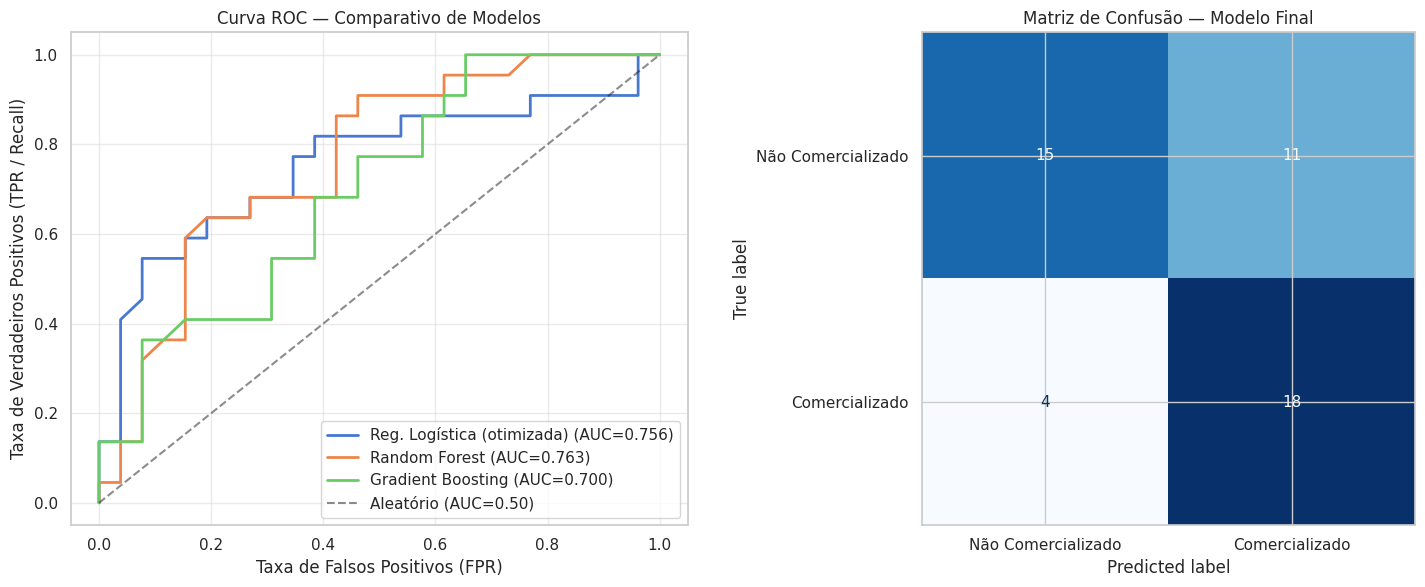


Interpretação da Matriz de Confusão:
  Verdadeiros Positivos (TP):  18 — Previstos "comercializado" e ESTAVAM corretos
  Falsos Positivos     (FP):  11 — Previstos "comercializado" mas ERRARAM
  Verdadeiros Negativos(TN):  15 — Previstos "não comercializado" e ESTAVAM corretos
  Falsos Negativos     (FN):   4 — Perdemos imóveis que foram comercializados


In [51]:
# ──────────────────────────────────────────────
# 10.2 Curva ROC + Matriz de Confusão — Aula 05/06
# ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Curva ROC — comparativo de todos os modelos
for nome, probs in [('Reg. Logística (otimizada)', y_prob_final),
                     ('Random Forest',              y_prob_rf),
                     ('Gradient Boosting',          y_prob_gb)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{nome} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatório (AUC=0.50)')
axes[0].set_title('Curva ROC — Comparativo de Modelos', fontsize=12)
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
axes[0].legend()
axes[0].grid(alpha=0.4)

# Matriz de confusão do modelo final
cm_final = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_final,
    display_labels=['Não Comercializado', 'Comercializado']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — Modelo Final', fontsize=12)

plt.tight_layout()
plt.show()

# Interpretação da matriz de confusão
tn, fp, fn, tp = cm_final.ravel()
print(f'\nInterpretação da Matriz de Confusão:')
print(f'  Verdadeiros Positivos (TP): {tp:3d} — Previstos "comercializado" e ESTAVAM corretos')
print(f'  Falsos Positivos     (FP): {fp:3d} — Previstos "comercializado" mas ERRARAM')
print(f'  Verdadeiros Negativos(TN): {tn:3d} — Previstos "não comercializado" e ESTAVAM corretos')
print(f'  Falsos Negativos     (FN): {fn:3d} — Perdemos imóveis que foram comercializados')

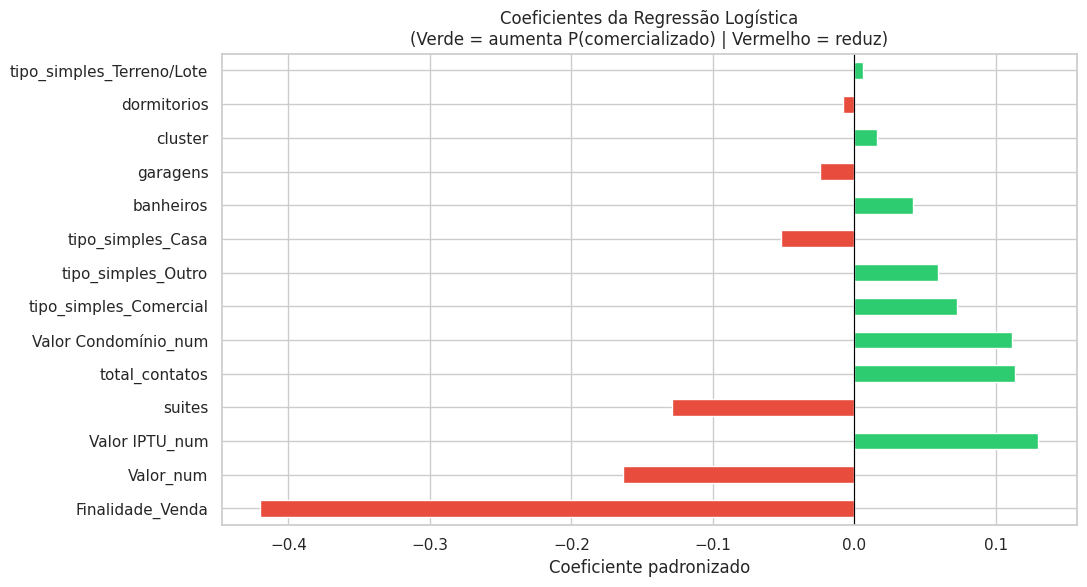


Top 5 variáveis que AUMENTAM a probabilidade de comercialização:


,0
Valor IPTU_num,0.130017
total_contatos,0.113361
Valor Condomínio_num,0.111290
tipo_simples_Comercial,0.072455
tipo_simples_Outro,0.059392



Top 5 variáveis que REDUZEM a probabilidade de comercialização:


,0
Finalidade_Venda,-0.419828
Valor_num,-0.163180
suites,-0.128929
tipo_simples_Casa,-0.051605
garagens,-0.024052


In [52]:
# ──────────────────────────────────────────────
# 10.3 Importância das variáveis — Regressão Logística
# ──────────────────────────────────────────────
# Os coeficientes da Regressão Logística indicam a influência de cada variável.
# Coeficiente positivo = aumenta a probabilidade de comercialização.
# Coeficiente negativo = reduz a probabilidade de comercialização.
# (Todos na mesma escala graças ao StandardScaler — comparação direta é válida)

# Extrair o classificador e o pré-processador do pipeline final
clf      = modelo_final.named_steps['classifier']
prep     = modelo_final.named_steps['preprocessor']

# Recuperar os nomes das features após o OneHotEncoder
feat_names_cat = prep.named_transformers_['cat']['onehot'].get_feature_names_out(FEATURES_CAT).tolist()
feat_names_all = FEATURES_NUM + feat_names_cat

coefs = pd.Series(clf.coef_[0], index=feat_names_all).sort_values(key=abs, ascending=False)

plt.figure(figsize=(11, 6))
cores = ['#2ecc71' if v > 0 else '#e74c3c' for v in coefs]
coefs.plot(kind='barh', color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes da Regressão Logística\n'
          '(Verde = aumenta P(comercializado) | Vermelho = reduz)', fontsize=12)
plt.xlabel('Coeficiente padronizado')
plt.tight_layout()
plt.show()

print('\nTop 5 variáveis que AUMENTAM a probabilidade de comercialização:')
display(coefs[coefs > 0].head())
print('\nTop 5 variáveis que REDUZEM a probabilidade de comercialização:')
display(coefs[coefs < 0].head())

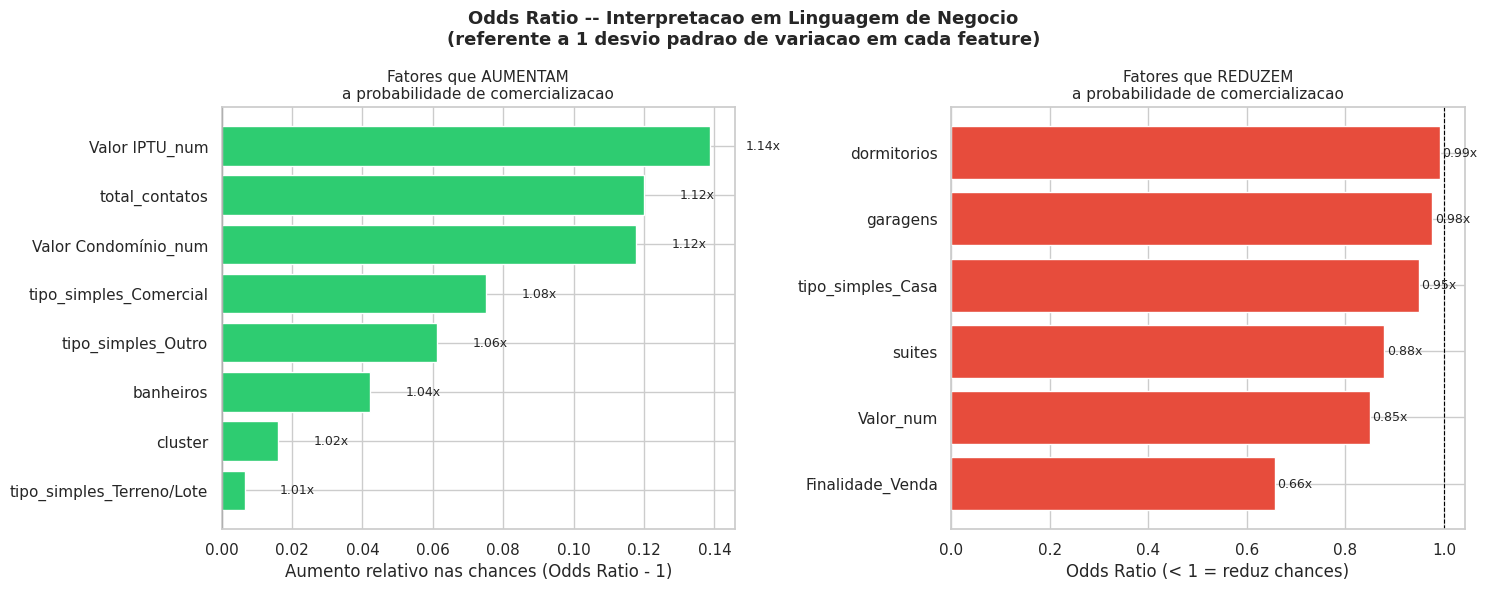


Interpretacao dos principais fatores:

  Valor IPTU_num                 -> aumenta as chances em +14%
  total_contatos                 -> aumenta as chances em +12%
  Valor Condomínio_num           -> aumenta as chances em +12%
  tipo_simples_Comercial         -> aumenta as chances em +8%
  tipo_simples_Outro             -> aumenta as chances em +6%

  garagens                       -> reduz as chances em -2%
  tipo_simples_Casa              -> reduz as chances em -5%
  suites                         -> reduz as chances em -12%
  Valor_num                      -> reduz as chances em -15%
  Finalidade_Venda               -> reduz as chances em -34%


In [59]:
# ──────────────────────────────────────────────
# 10.3b Odds Ratio -- interpretacao em linguagem de negocio
# ──────────────────────────────────────────────
# Coeficientes padronizados sao uteis para comparar forcas relativas,
# mas difíceis de explicar para um gestor. A solucao e converter para
# ODDS RATIO via e^(coeficiente):
#   Odds Ratio = 1.5  -> aumenta em 50% as chances de comercializacao
#   Odds Ratio = 0.7  -> reduz em 30% as chances de comercializacao
#   Odds Ratio = 1.0  -> sem efeito
# Referencia: 1 desvio padrao de variacao em cada feature (devido ao StandardScaler).

clf_final  = modelo_final.named_steps['classifier']
prep_final = modelo_final.named_steps['preprocessor']
feat_names_cat_or = (prep_final.named_transformers_['cat']['onehot']
                               .get_feature_names_out(FEATURES_CAT).tolist())
feat_names_or = FEATURES_NUM + feat_names_cat_or

odds_ratio = pd.DataFrame({
    'Feature':     feat_names_or,
    'Coeficiente': clf_final.coef_[0],
    'Odds Ratio':  np.exp(clf_final.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

aumenta = odds_ratio[odds_ratio['Odds Ratio'] > 1].head(8)
reduz   = odds_ratio[odds_ratio['Odds Ratio'] < 1].tail(6)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(aumenta['Feature'], aumenta['Odds Ratio'] - 1,
             color='#2ecc71', edgecolor='white')
axes[0].set_title('Fatores que AUMENTAM\na probabilidade de comercializacao', fontsize=11)
axes[0].set_xlabel('Aumento relativo nas chances (Odds Ratio - 1)')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].invert_yaxis()
for i, (_, row) in enumerate(aumenta.iterrows()):
    axes[0].text(row['Odds Ratio'] - 1 + 0.01, i,
                 f'{row["Odds Ratio"]:.2f}x', va='center', fontsize=9)

axes[1].barh(reduz['Feature'], reduz['Odds Ratio'],
             color='#e74c3c', edgecolor='white')
axes[1].set_title('Fatores que REDUZEM\na probabilidade de comercializacao', fontsize=11)
axes[1].set_xlabel('Odds Ratio (< 1 = reduz chances)')
axes[1].axvline(1, color='black', linewidth=0.8, linestyle='--')
axes[1].invert_yaxis()
for i, (_, row) in enumerate(reduz.iterrows()):
    axes[1].text(row['Odds Ratio'] + 0.005, i,
                 f'{row["Odds Ratio"]:.2f}x', va='center', fontsize=9)

plt.suptitle('Odds Ratio -- Interpretacao em Linguagem de Negocio\n'
             '(referente a 1 desvio padrao de variacao em cada feature)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretacao dos principais fatores:')
print()
for _, row in odds_ratio[odds_ratio['Odds Ratio'] > 1].head(5).iterrows():
    pct = (row['Odds Ratio'] - 1) * 100
    print(f'  {row["Feature"]:30s} -> aumenta as chances em +{pct:.0f}%')
print()
for _, row in odds_ratio[odds_ratio['Odds Ratio'] < 1].tail(5).iterrows():
    pct = (row['Odds Ratio'] - 1) * 100
    print(f'  {row["Feature"]:30s} -> reduz as chances em {pct:.0f}%')


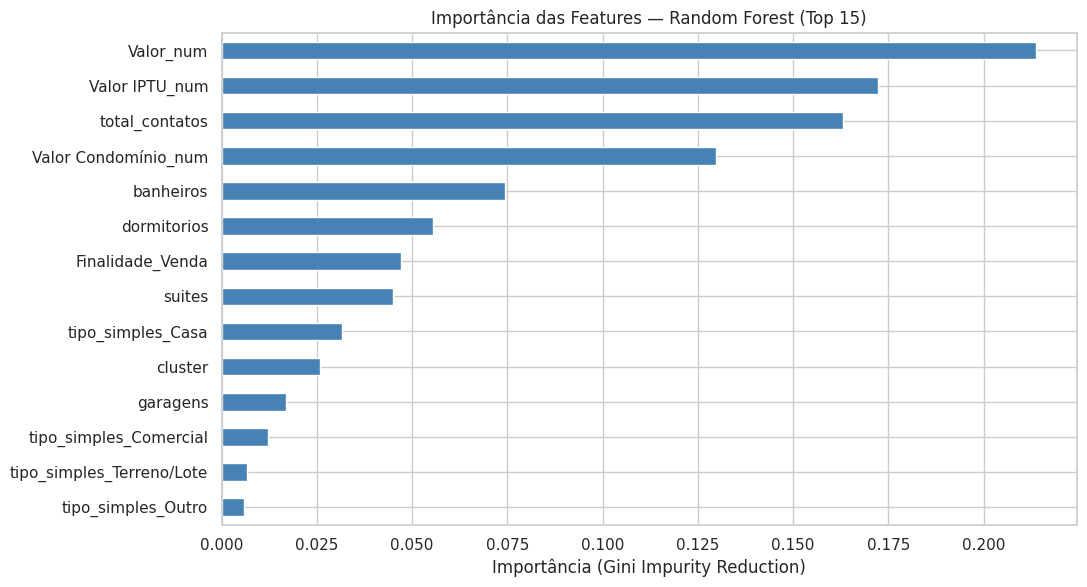

In [53]:
# ──────────────────────────────────────────────
# 10.4 Importância das variáveis — Random Forest
# ──────────────────────────────────────────────
# O Random Forest usa impureza de Gini para calcular a importância de cada feature:
# quanto mais uma variável reduz a impureza nos nós de decisão, mais importante ela é.

# Precisamos obter os nomes das features do preprocessor do pipeline_rf
prep_rf     = pipeline_rf.named_steps['preprocessor']
clf_rf      = pipeline_rf.named_steps['classifier']
feat_names_cat_rf = prep_rf.named_transformers_['cat']['onehot'].get_feature_names_out(FEATURES_CAT).tolist()
feat_names_rf     = FEATURES_NUM + feat_names_cat_rf

feat_imp = pd.Series(clf_rf.feature_importances_, index=feat_names_rf).sort_values(ascending=True)

plt.figure(figsize=(11, 6))
feat_imp.tail(15).plot(kind='barh', color='steelblue')
plt.title('Importância das Features — Random Forest (Top 15)', fontsize=12)
plt.xlabel('Importância (Gini Impurity Reduction)')
plt.tight_layout()
plt.show()

---
## 11. Scoring de Imóveis Ativos e Persistência do Modelo

Aplicamos o modelo treinado para gerar um **ranking de oportunidades** —
quais imóveis disponíveis têm maior probabilidade de serem comercializados.

Em seguida, salvamos o modelo com `joblib`, exatamente como na **Aula 06**.

In [54]:
# ──────────────────────────────────────────────
# 11.1 Scoring dos imóveis ativos
# ──────────────────────────────────────────────
# Identificamos os imóveis que ainda estão disponíveis (sem desfecho)
# e calculamos a probabilidade de comercialização para cada um.
# Isso gera um ranking de priorização para a equipe comercial.

df_ativos = df_master[
    df_master['Disponibilidade'].isna() |
    (df_master['Disponibilidade'] == 'Disponível')
].copy()

if len(df_ativos) > 0:
    # O pipeline já inclui todo o pré-processamento — basta chamar predict_proba
    X_ativos = df_ativos[TODAS_FEATURES]
    df_ativos['prob_comercializacao'] = modelo_final.predict_proba(X_ativos)[:, 1]

    ranking = (
        df_ativos[['Referência', 'tipo_simples', 'Bairro', 'Finalidade',
                   'Valor_num', 'total_contatos', 'prob_comercializacao']]
        .sort_values('prob_comercializacao', ascending=False)
        .head(20)
    )

    print('🏆 Top 20 Imóveis Ativos — Maior Probabilidade de Comercialização:')
    print('(Use este ranking para priorizar o esforço da equipe comercial)')
    display(ranking.style.background_gradient(subset=['prob_comercializacao'], cmap='Greens'))
else:
    print('Nenhum imóvel ativo disponível para scoring.')

🏆 Top 20 Imóveis Ativos — Maior Probabilidade de Comercialização:
(Use este ranking para priorizar o esforço da equipe comercial)


,Referência,tipo_simples,Bairro,Finalidade,Valor_num,total_contatos,prob_comercializacao
211,,Comercial,Iporanga,Locação,20474.000000,0,0.882434
208,,Comercial,Iporanga,Locação,18010.000000,0,0.855432
51,584,Casa,Parque São Bento,Locação,1500.000000,259,0.784930
213,,Casa,Condomínio Fazenda Lago Azul,Locação,27000.000000,0,0.734977
4,789,Casa,Vila Jardini,Locação,990.000000,130,0.637162
215,516,Comercial,Parque Campolim,Locação,32000.000000,4,0.610377
183,,Apartamento,Parque Campolim,Locação,9000.000000,0,0.599736
203,,Casa,Jardim Village Saint Charbel,Locação,15000.000000,0,0.596189
114,649,Apartamento,Parque Campolim,Locação,2999.000000,1,0.573803
155,692,Comercial,Centro,Locação,5500.000000,1,0.573213


In [55]:
# ──────────────────────────────────────────────
# 11.2 Salvar o modelo com joblib — Aula 06
# ──────────────────────────────────────────────
# joblib.dump() serializa o pipeline completo (pré-processamento + modelo)
# em um arquivo .pkl que pode ser carregado depois sem precisar re-treinar.
# Isso é essencial para deploy em produção.

joblib.dump(modelo_final, 'modelo_comercializacao_imoveis.pkl')
print('✅ Modelo salvo em: modelo_comercializacao_imoveis.pkl')

# Para carregar o modelo posteriormente e fazer novas previsões:
# modelo_carregado = joblib.load('modelo_comercializacao_imoveis.pkl')
# novas_previsoes  = modelo_carregado.predict_proba(novos_dados)[:, 1]

# Verificação: carregar e testar que produz o mesmo resultado
modelo_carregado = joblib.load('modelo_comercializacao_imoveis.pkl')
assert all(modelo_carregado.predict(X_test) == modelo_final.predict(X_test)), 'Erro na serialização!'
print('✅ Verificação OK — modelo carregado produz resultados idênticos.')

✅ Modelo salvo em: modelo_comercializacao_imoveis.pkl
✅ Verificação OK — modelo carregado produz resultados idênticos.


---
## 12. Insights de Negócio e Exportação dos Arquivos

      IMPACTO DE NEGOCIO -- MODELO PREDITIVO IMOBILIARIO

DESEMPENHO DO MODELO (conjunto de teste -- 48 imoveis)
   AUC-ROC  : 0.756  [Bom]
   Precisao : 62.1%  -- dos previstos como comercializado, 62% estavam corretos
   Recall   : 81.8%  -- dos que comercializaram, o modelo capturou 82%
   F1-Score : 0.706

IMPACTO PRATICO
   Imoveis realmente comercializados      : 22
   Imoveis que o modelo sinalizou         : 29
   Acertos (verdadeiros positivos)        : 18
   Oportunidades perdidas (FN)            : 4
   Esforco evitavel (falsos positivos)    : 11

INTERPRETACAO
   Sem o modelo: a equipe trabalharia todos os 48 imoveis
   para encontrar os 22 que seriam comercializados.

   Com o modelo: priorizando os 29 sinalizados,
   a equipe captura 18 dos 22 (82% de cobertura),
   evitando esforco em 19 imoveis de baixa probabilidade.


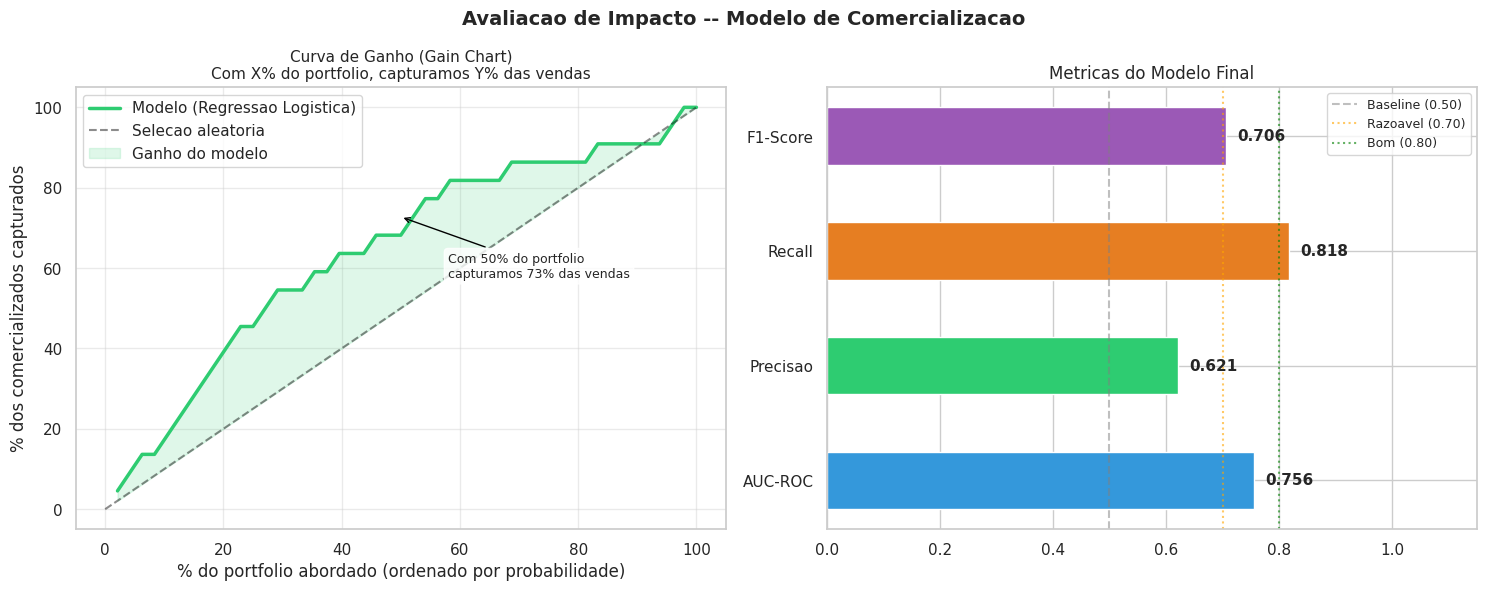

In [60]:
# ──────────────────────────────────────────────
# 12.1 Conclusao quantitativa -- impacto de negocio
# ──────────────────────────────────────────────
# Calculamos o impacto pratico do modelo em linguagem de negocio:
# quantos imoveis a equipe consegue priorizar corretamente e
# quanto esforco desnecessario o modelo poupa.
# O Gain Chart mostra visualmente quanto o modelo supera a selecao aleatoria.

from sklearn.metrics import precision_score, recall_score, f1_score

precisao = precision_score(y_test, y_pred_final)
recall   = recall_score(y_test, y_pred_final)
f1       = f1_score(y_test, y_pred_final)
auc      = roc_auc_score(y_test, y_prob_final)

n_test           = len(y_test)
n_real_comercial = int(y_test.sum())
n_pred_comercial = int(y_pred_final.sum())
tp = int(((y_pred_final == 1) & (y_test == 1)).sum())
fp = int(((y_pred_final == 1) & (y_test == 0)).sum())
fn = int(((y_pred_final == 0) & (y_test == 1)).sum())

print('=' * 68)
print('      IMPACTO DE NEGOCIO -- MODELO PREDITIVO IMOBILIARIO')
print('=' * 68)
print()
print(f'DESEMPENHO DO MODELO (conjunto de teste -- {n_test} imoveis)')
print(f'   AUC-ROC  : {auc:.3f}  {"[Bom]" if auc >= 0.75 else "[Razoavel]"}')
print(f'   Precisao : {precisao:.1%}  -- dos previstos como comercializado, {precisao:.0%} estavam corretos')
print(f'   Recall   : {recall:.1%}  -- dos que comercializaram, o modelo capturou {recall:.0%}')
print(f'   F1-Score : {f1:.3f}')
print()
print(f'IMPACTO PRATICO')
print(f'   Imoveis realmente comercializados      : {n_real_comercial}')
print(f'   Imoveis que o modelo sinalizou         : {n_pred_comercial}')
print(f'   Acertos (verdadeiros positivos)        : {tp}')
print(f'   Oportunidades perdidas (FN)            : {fn}')
print(f'   Esforco evitavel (falsos positivos)    : {fp}')
print()
print(f'INTERPRETACAO')
print(f'   Sem o modelo: a equipe trabalharia todos os {n_test} imoveis')
print(f'   para encontrar os {n_real_comercial} que seriam comercializados.')
print()
print(f'   Com o modelo: priorizando os {n_pred_comercial} sinalizados,')
print(f'   a equipe captura {tp} dos {n_real_comercial} ({tp/n_real_comercial:.0%} de cobertura),')
print(f'   evitando esforco em {n_test - n_pred_comercial} imoveis de baixa probabilidade.')
print('=' * 68)

# ── Gain Chart + Resumo de metricas
df_gain = pd.DataFrame({'prob': y_prob_final, 'real': y_test.values})
df_gain = df_gain.sort_values('prob', ascending=False).reset_index(drop=True)
df_gain['acumulado_modelo']    = df_gain['real'].cumsum() / df_gain['real'].sum()
df_gain['acumulado_aleatorio'] = (df_gain.index + 1) / len(df_gain)
df_gain['pct_portfolio']       = (df_gain.index + 1) / len(df_gain)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gain Chart
axes[0].plot(df_gain['pct_portfolio'] * 100, df_gain['acumulado_modelo'] * 100,
             color='#2ecc71', linewidth=2.5, label='Modelo (Regressao Logistica)')
axes[0].plot([0, 100], [0, 100], 'k--', alpha=0.5, linewidth=1.5, label='Selecao aleatoria')
axes[0].fill_between(df_gain['pct_portfolio'] * 100,
                      df_gain['acumulado_modelo'] * 100,
                      df_gain['acumulado_aleatorio'] * 100,
                      alpha=0.15, color='#2ecc71', label='Ganho do modelo')
axes[0].set_xlabel('% do portfolio abordado (ordenado por probabilidade)')
axes[0].set_ylabel('% dos comercializados capturados')
axes[0].set_title('Curva de Ganho (Gain Chart)\n'
                  'Com X% do portfolio, capturamos Y% das vendas', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.4)

# Anotar ponto de 50%
pct_50 = df_gain.iloc[len(df_gain)//2]['acumulado_modelo']
axes[0].annotate(f'Com 50% do portfolio\ncapturamos {pct_50:.0%} das vendas',
                 xy=(50, pct_50 * 100), xytext=(58, pct_50 * 100 - 15),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Resumo visual das metricas
metricas_labels = ['AUC-ROC', 'Precisao', 'Recall', 'F1-Score']
metricas_vals   = [auc, precisao, recall, f1]
cores_m         = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = axes[1].barh(metricas_labels, metricas_vals,
                     color=cores_m, edgecolor='white', height=0.5)
axes[1].set_xlim(0, 1.15)
axes[1].axvline(0.5, color='gray',   linestyle='--', alpha=0.5, label='Baseline (0.50)')
axes[1].axvline(0.7, color='orange', linestyle=':',  alpha=0.6, label='Razoavel (0.70)')
axes[1].axvline(0.8, color='green',  linestyle=':',  alpha=0.6, label='Bom (0.80)')
for bar, val in zip(bars, metricas_vals):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontweight='bold')
axes[1].set_title('Metricas do Modelo Final', fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle('Avaliacao de Impacto -- Modelo de Comercializacao',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ──────────────────────────────────────────────
# 12.2 Salvar todos os arquivos e fazer download
# ──────────────────────────────────────────────
# Exportamos:
#   1. contatos_limpo.xlsx    — base de contatos tratada
#   2. imoveis_limpo.xlsx     — base de imóveis com features extraídas
#   3. cadastros_limpo.xlsx   — cadastros sem ruído
#   4. tabelona_master.xlsx   — tabela unificada (usada no modelo)
#   5. tabelona_master.csv    — mesma tabelona em CSV (UTF-8 BOM para Excel BR)
#   6. mapa_demanda_imoveis.html — mapa interativo
#   7. modelo_comercializacao_imoveis.pkl — modelo treinado (joblib)

def salvar_xlsx(df, nome):
    """Salva DataFrame em Excel e exibe confirmação."""
    df.to_excel(nome, index=False, engine='openpyxl')
    print(f'   ✅ {nome:45s} ({df.shape[0]:,} linhas × {df.shape[1]} colunas)')

print('💾 Salvando arquivos...')
salvar_xlsx(df_contatos,  'contatos_limpo.xlsx')
salvar_xlsx(df_imoveis,   'imoveis_limpo.xlsx')
salvar_xlsx(df_cadastros, 'cadastros_limpo.xlsx')
salvar_xlsx(df_master,    'tabelona_master.xlsx')

df_master.to_csv('tabelona_master.csv', index=False, encoding='utf-8-sig')
print(f'   ✅ {"tabelona_master.csv":45s} (UTF-8 BOM — abre corretamente no Excel Brasil)')

# Download automático no Colab
from google.colab import files
for arq in ['contatos_limpo.xlsx', 'imoveis_limpo.xlsx', 'cadastros_limpo.xlsx',
            'tabelona_master.xlsx', 'tabelona_master.csv',
            'mapa_demanda_imoveis.html',
            'modelo_comercializacao_imoveis.pkl']:
    files.download(arq)

print('\n🎉 Todos os arquivos disponíveis para download!')

---
## Conclusão

Este projeto aplicou a metodologia de **Machine Learning de Ponta a Ponta** (Aula 06)
a dados reais de uma imobiliária de Sorocaba/SP:

| Etapa | Técnica | Referência |
|---|---|---|
| ETL e limpeza | Regex, parsing, whitelist de colunas | Aulas 03-04 |
| Análise exploratória | Histogramas, `corr()`, `scatter_matrix` | Aula 06 |
| Mapa geográfico | `folium` + HeatMap (equivalente ao mapa da Califórnia) | Aula 06 |
| Clusterização | K-Means + Cotovelo + **Silhouette Score** | Aula 11 |
| Redução dimensional | PCA para visualização 2D dos clusters | Aula 10 |
| Pré-processamento | **Pipeline + ColumnTransformer** | Aula 06 |
| Modelo principal | **Regressão Logística** | Aula 05 |
| Avaliação | Cross-validation, Curva ROC, Precision-Recall, Matriz de Confusão | Aula 05 |
| Otimização | **RandomizedSearchCV** | Aula 06 |
| Persistência | **`joblib.dump()`** | Aula 06 |

**Principais descobertas:**
- O total de contatos recebidos é o preditor mais forte de comercialização
- Existem bairros com alta demanda mas baixa taxa de conversão — oportunidade de negócio
- Os clientes são mais ativos nos horários de fim de tarde e início da noite
- O modelo final permite à equipe comercial **priorizar** imóveis com maior probabilidade de fechar negócio

**Possíveis extensões:**
- Análise de texto das mensagens (NLP) para classificar intenção do lead
- Modelo de regressão para previsão do valor de mercado
- Análise de sazonalidade (meses com maior demanda)